# Part 2: EDA & Prescriptive Analysis - DATATHON 2026

**Team:** GenCore | **Lead:** Trịnh Hoàng Tú

**Objective:** Extract actionable business insights from 11 datasets to drive growth and operational efficiency.


## 1. Business Objective, Scope, and Rubric Contract

**Business question:** where is realized revenue being eroded, why is that erosion happening, and which interventions should be prioritized to reduce leakage without compromising scale?

**Approach used to maximize the 60/60 rubric potential**
- `Descriptive`: establish the 2022 picture of GMV, realized net revenue, leakage, and mix.
- `Diagnostic`: keep only the three strongest drivers in the main story: `cancellation friction`, `wrong-size return`, and `promotion erosion (proxy)`.
- `Predictive`: use the model as a **triage layer** under an operational review capacity of roughly `15%` of orders, not as a standalone decision engine.
- `Prescriptive`: prioritize actions by `evidence strength + recoverable leakage value`, with clear owners, KPIs, and a `30-60-90 day` roadmap.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")

try:
    from IPython.display import Markdown, display
except Exception:
    class Markdown(str):
        pass

    def display(obj):
        print(obj)

from src import eda

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
eda.set_plot_theme()

DATA_PATH = PROJECT_ROOT / "data" / "raw"
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATA_PATH = {DATA_PATH}")


PROJECT_ROOT = D:\Projects\Datathon2026-TheGridbreakers-GenCore
DATA_PATH = D:\Projects\Datathon2026-TheGridbreakers-GenCore\data\raw


In [2]:
raw = eda.load_data(str(DATA_PATH))
table_bundle = eda.preview_table_bundle(raw)
display(table_bundle)

print(f"Total tables loaded: {len(raw)} / 14")


,table,rows,cols,date_min,date_max
0,order_items,714669,7,NaN,NaN
1,orders,646945,8,2012-07-04,2022-12-31
2,payments,646945,4,NaN,NaN
3,shipments,566067,4,2012-07-04,2022-12-31
4,customers,121930,7,2012-01-17,2022-12-31
5,reviews,113551,7,2012-07-10,2022-12-31
6,inventory,60247,17,2012-07-31,2022-12-31
7,geography,39948,4,NaN,NaN
8,returns,39939,7,2012-07-11,2022-12-31
9,sales,3833,3,2012-07-04,2022-12-31


Total tables loaded: 14 / 14


In [3]:
quality_audit = eda.build_quality_audit(str(DATA_PATH))
relation_summary = eda.build_relation_summary(raw)

display(quality_audit)
display(relation_summary)


,Ten File,Tong dong,Cot loi Type,% Missing cao nhat,So dong trung,Van de Logic (Outlier/Min-Max),PK unique,Memory (MB),Date range
0,products.csv,2412,none,0.00% (none),0,"outlier_iqr:cogs=37,price=31",True,0.7090,n/a
1,customers.csv,121930,none,0.00% (none),0,no_major_issue_detected,True,34.9800,signup_date: 2012-01-17 -> 2022-12-31
2,promotions.csv,50,none,80.00% (applicable_category),0,high_missing:applicable_category=80.00%; outli...,True,0.0200,start_date: 2013-01-31 -> 2022-11-18 | end_dat...
3,geography.csv,39948,none,0.00% (none),0,no_major_issue_detected,True,6.8640,n/a
4,orders.csv,646945,none,0.00% (none),0,no_major_issue_detected,True,194.2420,order_date: 2012-07-04 -> 2022-12-31
5,order_items.csv,714669,none,99.97% (promo_id_2),0,high_missing:promo_id_2=99.97%; pk_not_unique;...,False,78.0030,n/a
6,payments.csv,646945,none,0.00% (none),0,outlier_iqr:payment_value=30219,True,50.5640,n/a
7,shipments.csv,566067,none,0.00% (none),0,outlier_iqr:shipping_fee=76050,True,72.3390,ship_date: 2012-07-04 -> 2022-12-29 | delivery...
8,returns.csv,39939,none,0.00% (none),0,outlier_iqr:refund_amount=2778,True,8.0180,return_date: 2012-07-11 -> 2022-12-31
9,reviews.csv,113551,none,0.00% (none),0,no_major_issue_detected,True,23.2790,review_date: 2012-07-10 -> 2022-12-31


,relation,left_unique,right_unique,intersection,left_only,right_only,coverage_from_left,coverage_from_right
0,orders -> payments,646945,646945,646945,0,0,1.0000,1.0000
1,orders -> shipments,646945,566067,566067,80878,0,0.8750,1.0000
2,order_items -> products,1598,2412,1598,0,814,1.0000,0.6625
3,returns -> orders,36062,646945,36062,0,610883,1.0000,0.0557
4,reviews -> orders,111369,646945,111369,0,535576,1.0000,0.1721


## 2. Data Assumptions, KPI Dictionary, and Caveats

- `GMV`: order value before outcome adjustments; `realized net revenue`: revenue retained after leakage from `cancellations` and `returns`.
- `Leakage value`: total revenue lost due to `cancellations` and `returns` on resolved orders.
- `Promo analysis` is used as a **proxy diagnostic** and should not be interpreted as definitive causal evidence.
- The `predictive section` is used to prioritize review queues under limited operational capacity, not to replace business rules entirely.
- We reviewed weaker or less stable signals such as `delivery delay` and `stockout`, but we did not elevate them into the core action story.


In [4]:
fact_line, fact_order = eda.build_fact_tables(raw)
recent_year = int(fact_order["order_year"].max())

price_check = raw["order_items"][["product_id", "quantity", "unit_price", "discount_amount"]].merge(
    raw["products"][["product_id", "price"]],
    on="product_id",
    how="left",
)
price_check = price_check.loc[
    price_check["price"].notna() & price_check["quantity"].gt(0) & price_check["unit_price"].notna()
].copy()
price_check["implied_pre"] = price_check["unit_price"] + (
    price_check["discount_amount"] / price_check["quantity"]
)

unit_gap = (price_check["unit_price"] - price_check["price"]).abs().median()
implied_gap = (price_check["implied_pre"] - price_check["price"]).abs().median()
pricing_mode = "post-discount" if implied_gap + 1e-9 < unit_gap else "pre-discount"

gmv_check = pd.DataFrame(
    [
        {"check": "unit_price vs catalog price gap (median abs)", "value": float(unit_gap)},
        {"check": "implied_pre vs catalog price gap (median abs)", "value": float(implied_gap)},
        {"check": "inferred unit_price basis", "value": pricing_mode},
    ]
)

integrity_checks = pd.DataFrame(
    [
        {
            "check": "fact_line rows",
            "value": len(fact_line),
            "comment": "No abnormal row inflation after joins.",
        },
        {
            "check": "fact_order rows",
            "value": len(fact_order),
            "comment": "Matches the number of unique order IDs.",
        },
        {
            "check": "order_id unique in fact_order",
            "value": int(fact_order["order_id"].nunique()),
            "comment": "Primary mart used for KPIs, modeling, and action sizing.",
        },
        {
            "check": "resolved share",
            "value": round(fact_order["is_resolved"].mean(), 4),
            "comment": "Leakage rate is interpreted on resolved flow only.",
        },
        {
            "check": "in-flight share",
            "value": round(fact_order["is_in_flight"].mean(), 4),
            "comment": "Created / paid / shipped remain in the pipeline until an outcome is observed.",
        },
        {
            "check": "shipment coverage",
            "value": round(fact_order["delivery_days"].notna().mean(), 4),
            "comment": "Coverage is sufficient to review shipping as a caveat, but not to support a core action.",
        },
    ]
)

display(gmv_check)
display(integrity_checks)


,check,value
0,unit_price vs catalog price gap (median abs),134.1468
1,implied_pre vs catalog price gap (median abs),65.0183
2,inferred unit_price basis,post-discount


,check,value,comment
0,fact_line rows,"714,669.0000",No abnormal row inflation after joins.
1,fact_order rows,"646,945.0000",Matches the number of unique order IDs.
2,order_id unique in fact_order,"646,945.0000","Primary mart used for KPIs, modeling, and acti..."
3,resolved share,0.9465,Leakage rate is interpreted on resolved flow o...
4,in-flight share,0.0535,Created / paid / shipped remain in the pipelin...
5,shipment coverage,0.8750,Coverage is sufficient to review shipping as a...


## 3. Descriptive Analysis - What Happened?


,metric,year,value,previous_value,yoy_change
0,GMV,2022,"1,224,190,566.8800","1,094,865,465.5400",0.1181
1,Realized net revenue,2022,"933,627,565.6700","831,126,558.1500",0.1233
2,Cancellation leakage,2022,"108,686,866.5700","96,097,529.1800",0.1310
3,Return leakage,2022,"34,621,315.5200","32,453,585.4000",0.0668
4,Total leakage value,2022,"143,308,182.0900","128,551,114.5800",0.1148


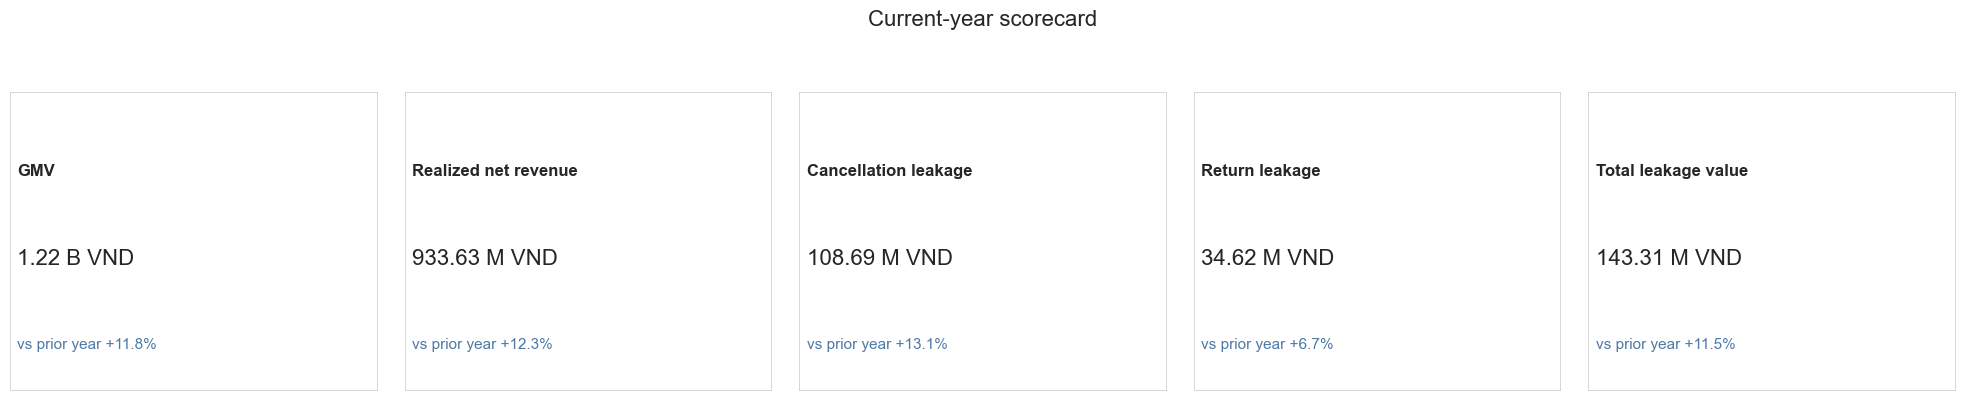

Quarterly KPI view (latest 8 quarters)


,quarter,gmv,booked_net_revenue,realized_net_revenue,booked_cogs,resolved_orders,in_flight_orders,leakage_orders,return_orders,cancelled_orders,total_discount,cancel_leakage,return_leakage,aov,return_rate,cancel_rate,leakage_rate
34,2021-01-01,"234,136,908.5500","225,824,739.6200","178,250,926.4500","187,891,991.2684",6788,566,1107,401,706,"8,312,168.9300","22,257,361.5800","6,982,742.7200","26,259.7122",0.0591,0.1040,0.1631
35,2021-04-01,"418,488,600.1400","406,357,158.6600","325,299,581.8600","340,124,592.1419",11584,992,1784,702,1082,"12,131,441.4800","35,762,527.7100","12,871,479.1200","28,081.8009",0.0606,0.0934,0.1540
36,2021-07-01,"261,471,765.0800","244,123,379.3800","194,512,768.8900","261,005,825.2336",8239,709,1326,486,840,"17,348,385.7000","22,938,041.5200","7,189,262.9200","23,608.7837",0.0590,0.1020,0.1609
37,2021-10-01,"180,768,191.7700","166,734,541.9700","133,063,280.9500","152,107,711.5175",5197,450,850,329,521,"14,033,649.8000","15,139,598.3700","5,410,100.6400","25,603.8640",0.0633,0.1003,0.1636
38,2022-01-01,"285,182,898.2800","276,304,531.1000","222,093,844.9800","237,804,003.8085",7476,656,1172,434,738,"8,878,367.1800","24,631,265.6000","7,730,933.7700","29,707.5769",0.0581,0.0987,0.1568
39,2022-04-01,"429,252,589.3000","416,145,822.6600","332,992,240.9400","356,024,022.1124",11607,1026,1892,676,1216,"13,106,766.6400","38,763,783.6600","11,767,878.5000","28,688.9154",0.0582,0.1048,0.1630
40,2022-07-01,"315,702,433.5400","297,449,007.7800","236,466,668.1600","264,034,549.3150",8321,718,1397,561,836,"18,253,425.7600","27,307,977.9700","10,549,913.1200","28,418.0589",0.0674,0.1005,0.1679
41,2022-10-01,"194,052,645.7600","179,849,470.1500","142,074,811.5900","162,557,588.7095",5690,510,945,351,594,"14,203,175.6100","17,983,839.3400","4,572,590.1300","24,969.2112",0.0617,0.1044,0.1661


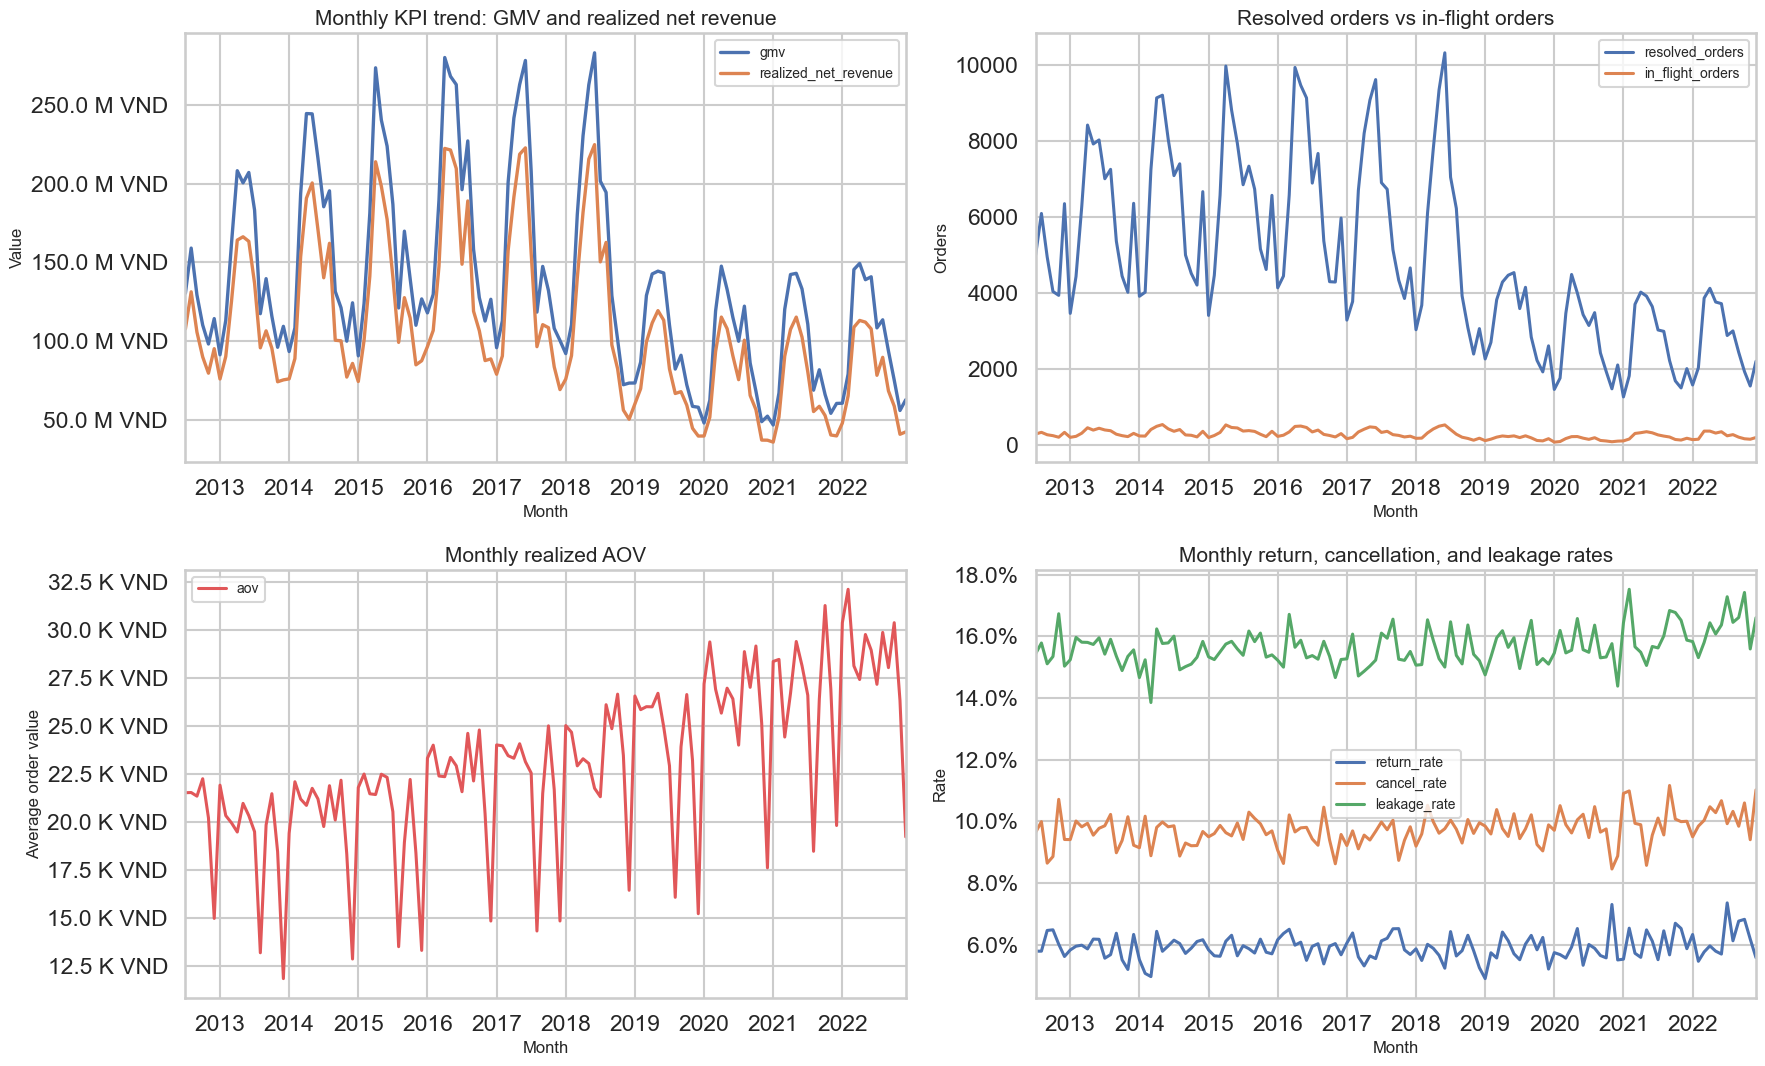

In [5]:
monthly_kpis = eda.build_monthly_kpis(fact_order)
quarterly_kpis = eda.build_quarterly_kpis(monthly_kpis)
geo_snapshot = eda.build_geography_snapshot(fact_order)
recon_df = eda.reconcile_with_sales(monthly_kpis, raw["sales"])
scorecard = eda.build_descriptive_scorecard(fact_order, recent_year=recent_year)

display(scorecard)
eda.plot_descriptive_scorecard(scorecard)

print("Quarterly KPI view (latest 8 quarters)")
display(quarterly_kpis.tail(8))
eda.plot_kpi_trends(monthly_kpis)


### 3.1 Seasonal Decomposition (Predictive Bridge)

This section is used to visualize the **trend + seasonality** of monthly revenue and support the predictive framing. It is not used to assert an operational root cause.


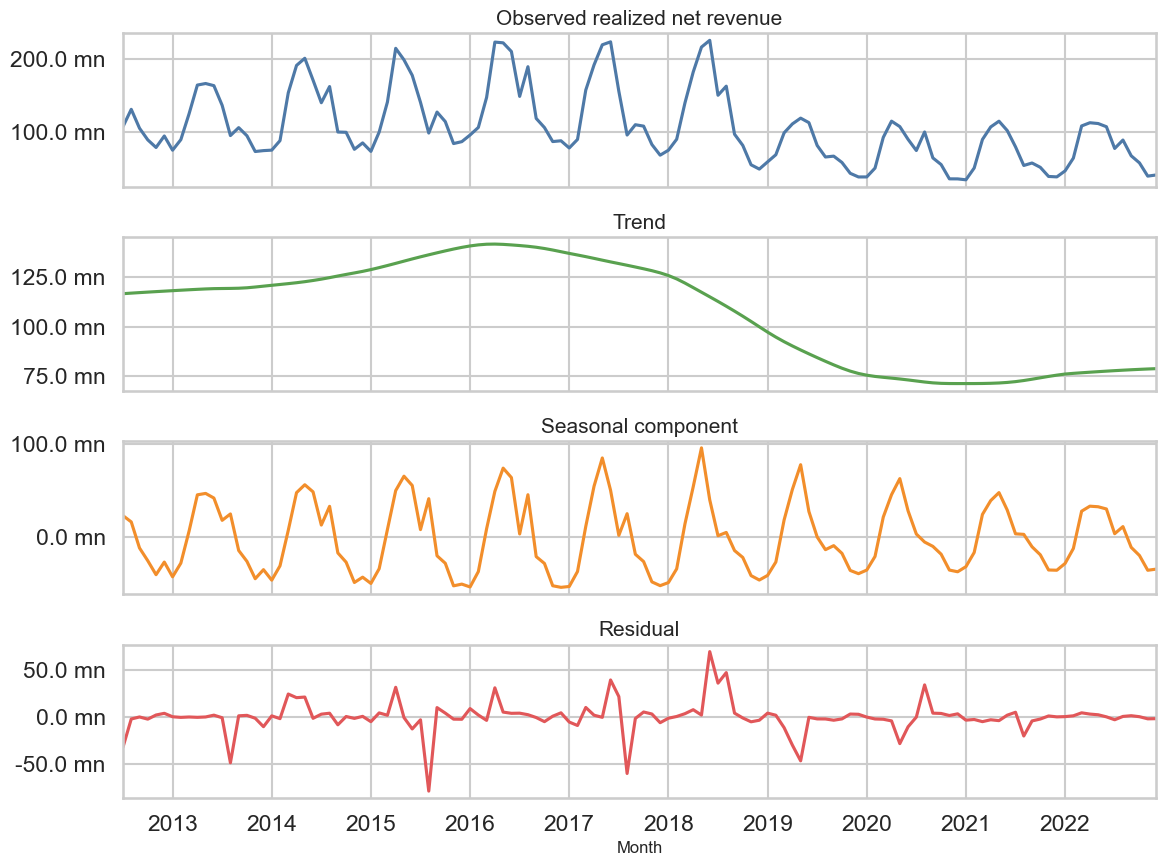

,month,seasonal_index
4,5,"64,671,994.0510"
3,4,"47,235,336.3003"
5,6,"41,711,229.7738"
7,8,"17,161,556.5305"


**Seasonality bridge:** STL decomposition shows `May` as the month with the strongest seasonal uplift; the predictive layer should therefore separate seasonality from operational risk signals.

In [6]:
monthly_ts = monthly_kpis.set_index("order_month")["realized_net_revenue"].sort_index()
monthly_ts = monthly_ts.asfreq("MS")
monthly_ts = monthly_ts.interpolate(limit_direction="both")

if monthly_ts.notna().sum() >= 24:
    seasonal_method = "fallback"
    observed = monthly_ts.copy()

    try:
        from statsmodels.tsa.seasonal import STL

        stl = STL(monthly_ts, period=12, robust=True)
        stl_result = stl.fit()
        trend = pd.Series(stl_result.trend, index=monthly_ts.index)
        seasonal = pd.Series(stl_result.seasonal, index=monthly_ts.index)
        resid = pd.Series(stl_result.resid, index=monthly_ts.index)
        seasonal_method = "STL"
    except Exception:
        trend = monthly_ts.rolling(window=12, center=True, min_periods=6).mean()
        trend = trend.interpolate(limit_direction="both")
        detrended = monthly_ts - trend
        month_lookup = detrended.groupby(detrended.index.month).mean()
        seasonal = pd.Series(detrended.index.month, index=monthly_ts.index).map(month_lookup).astype(float)
        resid = monthly_ts - trend - seasonal

    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    observed.plot(ax=axes[0], color="#4E79A7", title="Observed realized net revenue")
    trend.plot(
        ax=axes[1],
        color="#59A14F",
        title="Trend" if seasonal_method == "STL" else "Trend (12M rolling mean fallback)",
    )
    seasonal.plot(
        ax=axes[2],
        color="#F28E2B",
        title="Seasonal component" if seasonal_method == "STL" else "Seasonal index (month-of-year fallback)",
    )
    resid.plot(
        ax=axes[3],
        color="#E15759",
        title="Residual" if seasonal_method == "STL" else "Residual (after fallback decomposition)",
    )

    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _pos: f"{y/1e6:.1f} mn"))
    axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _pos: f"{y/1e6:.1f} mn"))
    axes[2].yaxis.set_major_formatter(FuncFormatter(lambda y, _pos: f"{y/1e6:.1f} mn"))
    axes[3].yaxis.set_major_formatter(FuncFormatter(lambda y, _pos: f"{y/1e6:.1f} mn"))
    axes[3].set_xlabel("Month")

    plt.tight_layout()
    plt.show()

    seasonal_rank = (
        pd.Series(seasonal.values, index=monthly_ts.index)
        .groupby(monthly_ts.index.month)
        .mean()
        .rename("seasonal_index")
        .reset_index()
        .rename(columns={"index": "month", "order_month": "month"})
        .sort_values("seasonal_index", ascending=False)
    )
    seasonal_rank["month"] = seasonal_rank["month"].astype(int)
    display(seasonal_rank.head(4))

    top_month = int(seasonal_rank.iloc[0]["month"])
    top_month_name = pd.Timestamp(year=recent_year, month=top_month, day=1).strftime("%B")
    method_note = (
        "STL decomposition"
        if seasonal_method == "STL"
        else "fallback decomposition using a rolling trend plus a month-of-year index"
    )
    display(
        Markdown(
            f"**Seasonality bridge:** {method_note} shows `{top_month_name}` as the month with the strongest seasonal uplift; "
            "the predictive layer should therefore separate seasonality from operational risk signals."
        )
    )
else:
    print("The time series is not yet long enough (>=24 months) for a stable decomposition.")


,stage,value
0,GMV,"16,249,922,486.8400"
1,Discounts,"-709,397,088.3100"
2,Cancellation leakage,"-1,515,891,006.1900"
3,Return leakage,"-510,660,319.5900"
4,Realized net revenue,"13,513,974,072.7500"


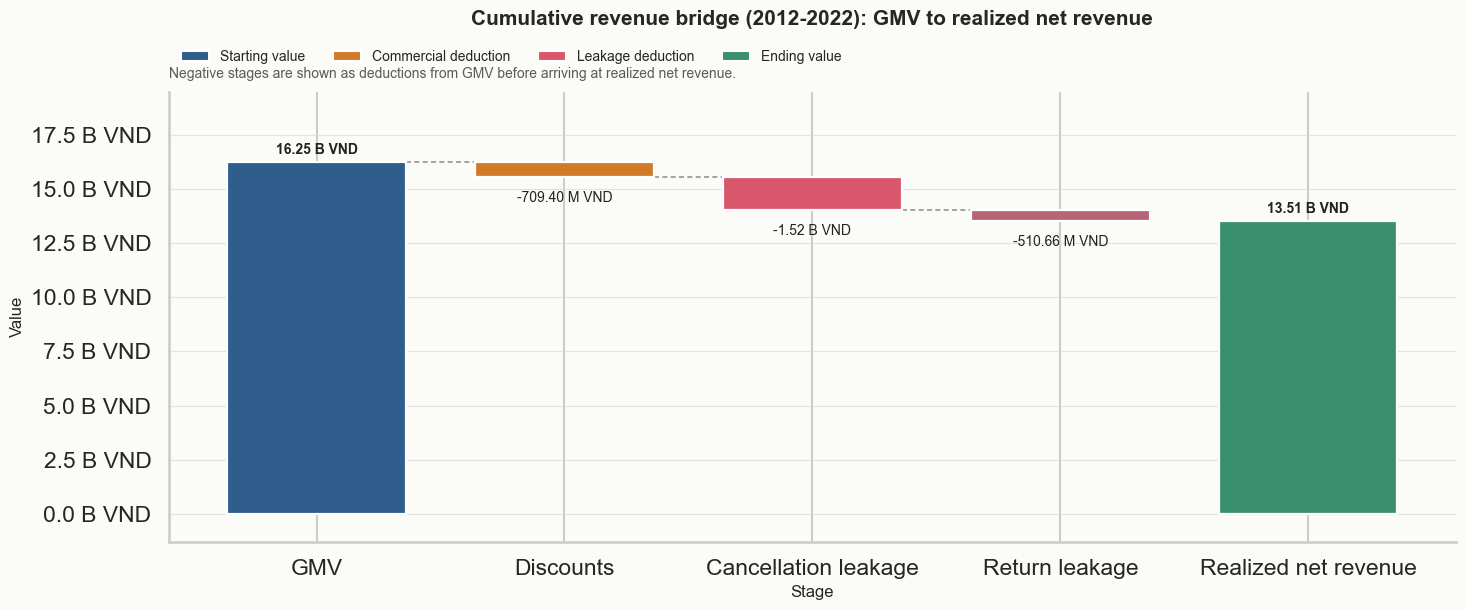

sales.csv reconciliation using the correct metric definitions (latest 12 months)


,order_month,sales_revenue,booked_net_revenue,realized_net_revenue,sales_cogs,booked_cogs,alignment_ratio,cogs_alignment_ratio,realized_gap_vs_sales,outcome_leakage_ratio
114,2022-01-01,"59,663,486.3200","59,663,486.3200","47,998,346.1800","50,851,459.6000","50,851,459.6196",1.0000,1.0000,"11,665,140.1400",0.1955
115,2022-02-01,"79,103,095.5000","79,103,095.5000","65,272,804.7900","65,285,573.1300","65,285,573.1639",1.0000,1.0000,"13,830,290.7100",0.1748
116,2022-03-01,"137,537,949.2800","137,537,949.2800","108,822,694.0100","121,666,971.0000","121,666,971.0251",1.0000,1.0000,"28,715,255.2700",0.2088
117,2022-04-01,"141,305,508.8100","141,305,508.8100","113,154,675.5600","124,361,629.9700","124,361,629.9605",1.0000,1.0000,"28,150,833.2500",0.1992
118,2022-05-01,"139,027,887.1600","139,027,887.1600","112,074,196.4300","113,951,506.2700","113,951,506.2542",1.0000,1.0000,"26,953,690.7300",0.1939
119,2022-06-01,"135,812,426.6900","135,812,426.6900","107,763,368.9500","117,710,885.9300","117,710,885.8978",1.0000,1.0000,"28,049,057.7400",0.2065
120,2022-07-01,"98,141,777.7200","98,141,777.7200","78,328,536.7900","91,605,928.7200","91,605,928.7213",1.0000,1.0000,"19,813,240.9300",0.2019
121,2022-08-01,"113,542,943.4700","113,542,943.4700","89,736,375.9500","94,033,378.3400","94,033,378.3350",1.0000,1.0000,"23,806,567.5200",0.2097
122,2022-09-01,"85,764,286.5900","85,764,286.5900","68,401,755.4200","78,395,242.2700","78,395,242.2586",1.0000,1.0000,"17,362,531.1700",0.2024
123,2022-10-01,"75,194,452.3100","75,194,452.3100","58,790,348.3100","61,969,893.8000","61,969,893.7692",1.0000,1.0000,"16,404,104.0000",0.2182


## Sales reconciliation note
- `sales.csv Revenue` aligns with **booked net revenue** = `GMV - discount`, not with `realized net revenue` after final outcomes.
- The gap between `sales.csv` and `realized net revenue` is therefore **expected post-outcome leakage**, not a join failure or KPI-construction error.
- In the current data, monthly alignment between `booked net revenue` / `booked COGS` and `sales.csv` is effectively `100%`.

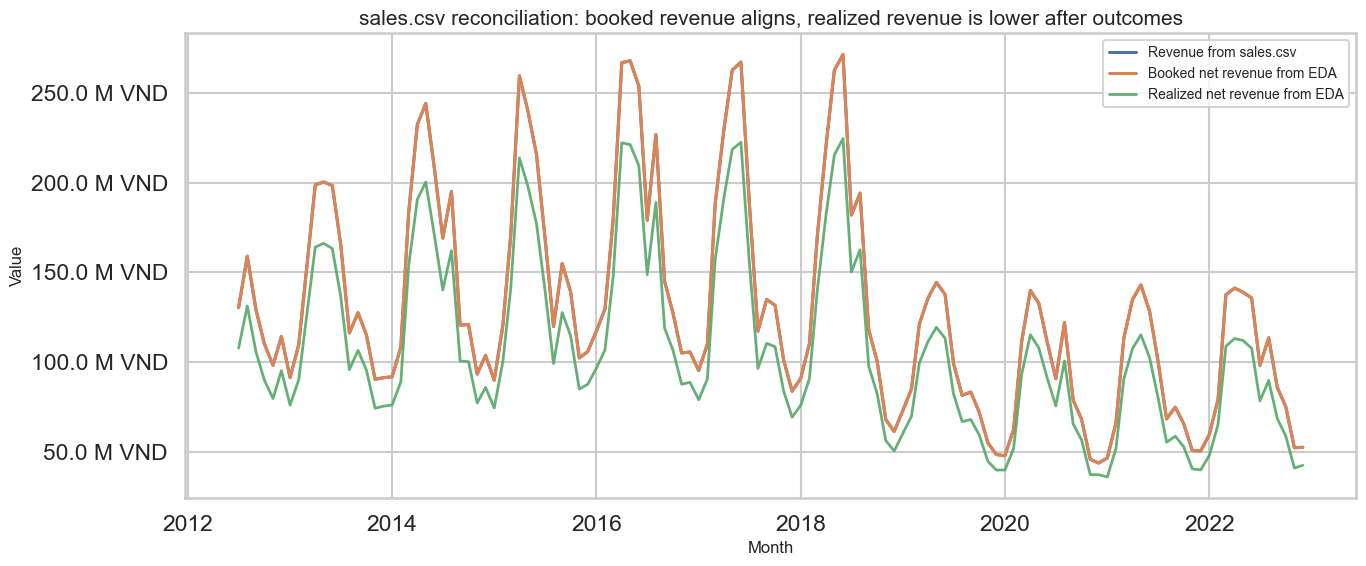

In [7]:
waterfall_df = eda.build_waterfall_summary(fact_order)
display(waterfall_df)
eda.plot_waterfall(waterfall_df)

recon_cols = [
    "order_month",
    "sales_revenue",
    "booked_net_revenue",
    "realized_net_revenue",
    "sales_cogs",
    "booked_cogs",
    "alignment_ratio",
    "cogs_alignment_ratio",
    "realized_gap_vs_sales",
    "outcome_leakage_ratio",
]
print("sales.csv reconciliation using the correct metric definitions (latest 12 months)")
display(recon_df[recon_cols].tail(12))
display(
    Markdown(
        "## Sales reconciliation note\n"
        "- `sales.csv Revenue` aligns with **booked net revenue** = `GMV - discount`, not with `realized net revenue` after final outcomes.\n"
        "- The gap between `sales.csv` and `realized net revenue` is therefore **expected post-outcome leakage**, not a join failure or KPI-construction error.\n"
        "- In the current data, monthly alignment between `booked net revenue` / `booked COGS` and `sales.csv` is effectively `100%`."
    )
)
eda.plot_sales_reconciliation(recon_df)


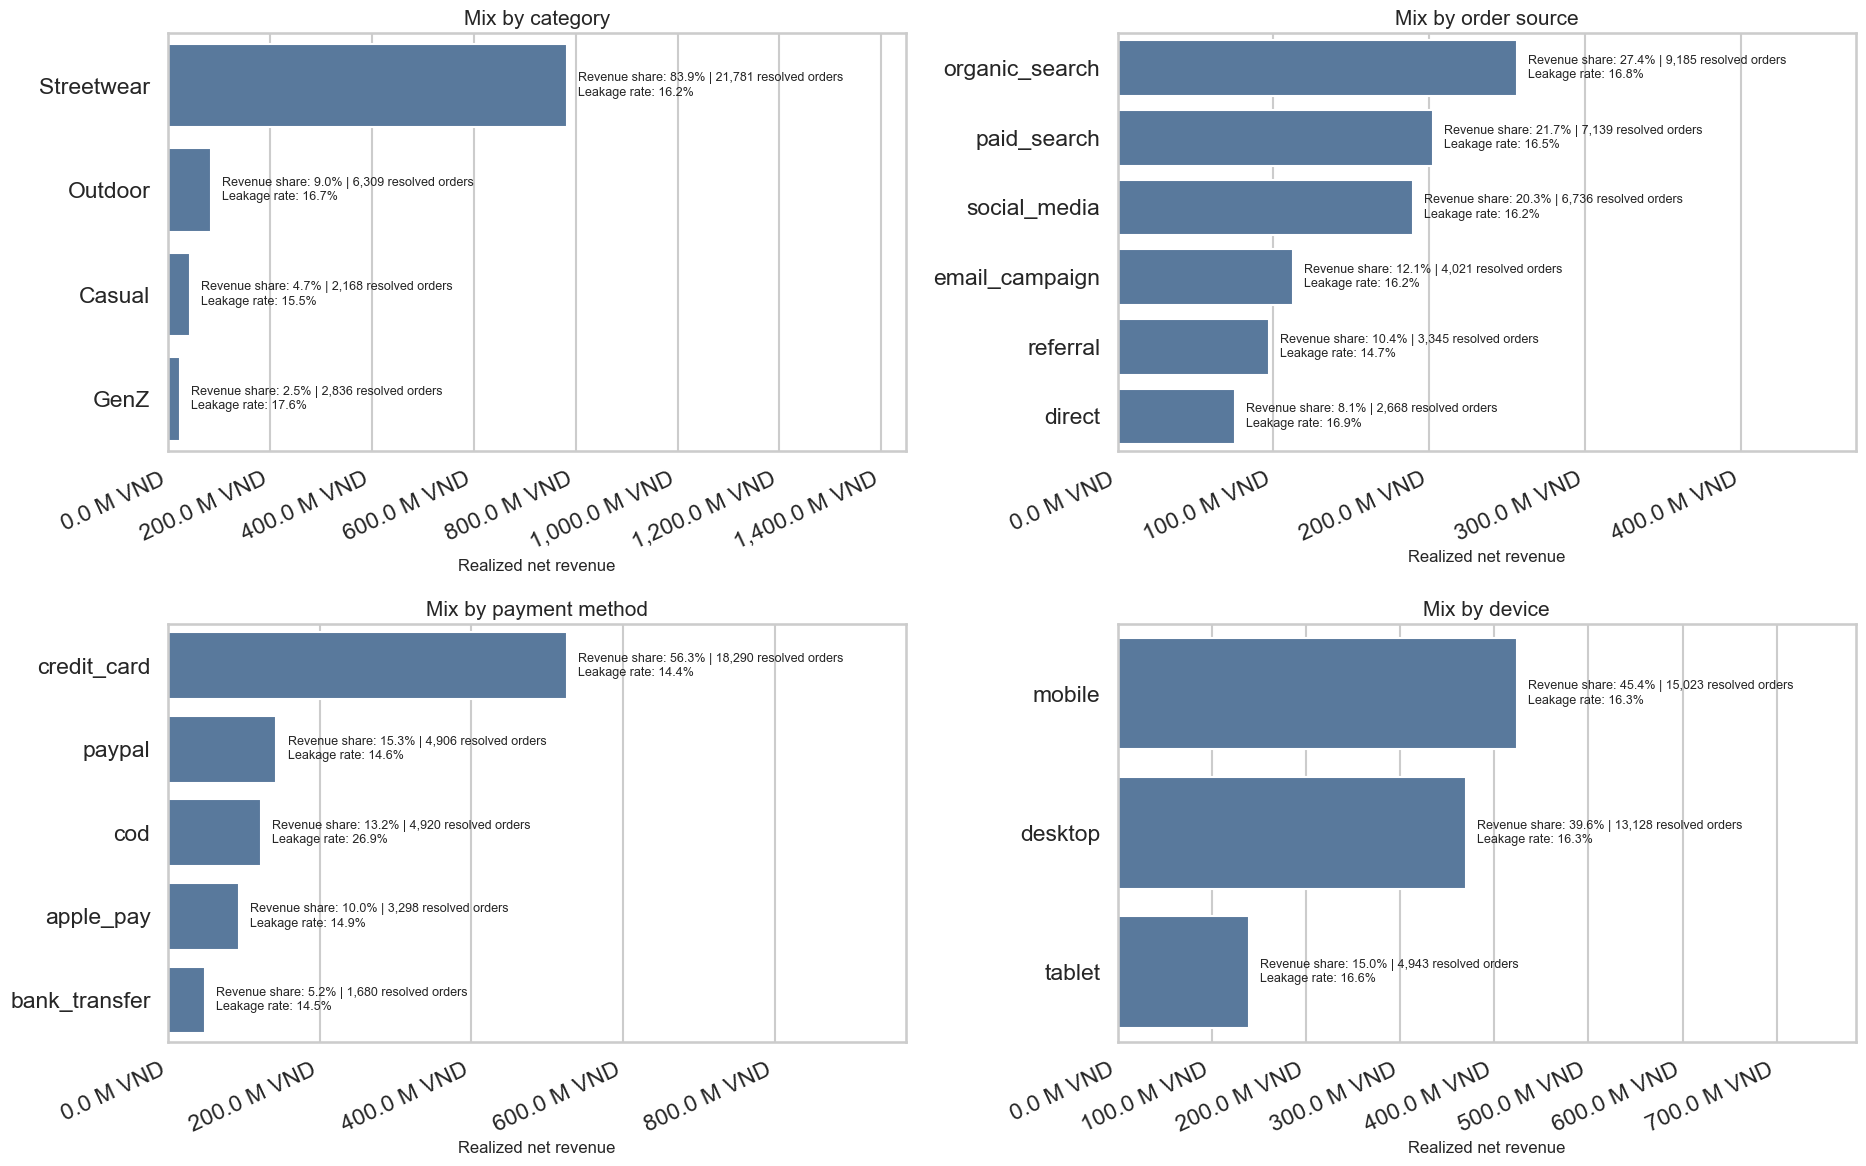

,region,realized_net_revenue,resolved_orders,return_orders,cancelled_orders,avg_delivery_days,return_rate,cancel_rate
1,East,"435,267,584.5600",15203,926,1584,4.5139,0.0609,0.1042
0,Central,"306,961,865.9700",10318,649,1055,4.5115,0.0629,0.1022
2,West,"191,398,115.1400",7573,447,745,4.5055,0.0590,0.0984


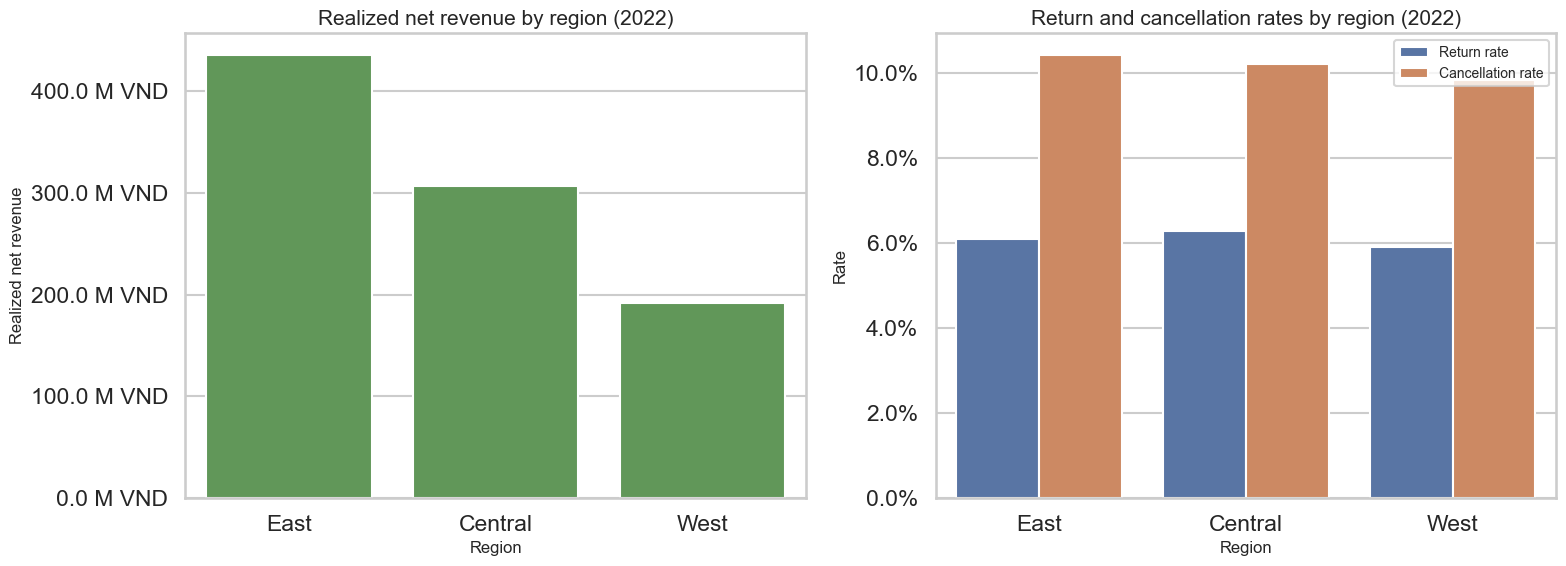

In [8]:
eda.plot_mix_dashboard(fact_order, recent_year=recent_year)
display(geo_snapshot)
eda.plot_geography_snapshot(geo_snapshot)


In [9]:
descriptive_points = eda.build_descriptive_summary(monthly_kpis, fact_order, geo_snapshot)
descriptive_md = "## Descriptive takeaways\n" + "\n".join([f"- {point}" for point in descriptive_points])
display(Markdown(descriptive_md))


## Descriptive takeaways
- In 2022, realized net revenue reached 933.63 M VND, changing +12.3% YoY, while total leakage value reached 143.31 M VND (+11.5% YoY).
- The strongest month was 04/2022 with 113.15 M VND in realized net revenue, while the month with the highest leakage pressure was 10/2022 at 17.4%.
- Streetwear led 83.9% of realized net revenue and 65.8% of resolved volume in 2022; East contributed 46.6% of realized net revenue, while 91.9% of the year's flow had already reached a final outcome.

### 3.2 Web Traffic Bridge (Leading Indicator)

Web traffic is used as a **leading indicator** to connect demand behavior with realized revenue. This section strengthens the storyline, but it should not drive action unless supported by direct diagnostic evidence.


,gmv,realized_net_revenue,sessions,unique_visitors,avg_bounce,avg_session_duration_sec,avg_pages_per_session
gmv,1.0000,0.9952,0.4474,0.4470,-0.1050,-0.1533,0.0274
realized_net_revenue,0.9952,1.0000,0.4445,0.4444,-0.1029,-0.1489,0.0237
sessions,0.4474,0.4445,1.0000,0.9998,-0.0350,-0.1252,0.0624
unique_visitors,0.4470,0.4444,0.9998,1.0000,-0.0364,-0.1297,0.0642
avg_bounce,-0.1050,-0.1029,-0.0350,-0.0364,1.0000,-0.0575,-0.1074
avg_session_duration_sec,-0.1533,-0.1489,-0.1252,-0.1297,-0.0575,1.0000,0.0002
avg_pages_per_session,0.0274,0.0237,0.0624,0.0642,-0.1074,0.0002,1.0000


,traffic_source,total_sessions,avg_bounce,avg_session_duration_sec,avg_pages_per_session
1,email_campaign,12792670,0.0045,213.2206,4.3207
5,social_media,15816226,0.0045,210.2902,4.3138
3,paid_search,19598271,0.0045,209.3621,4.3291
4,referral,9476845,0.0045,207.5587,4.3906
2,organic_search,27196976,0.0045,211.1539,4.3237
0,direct,6571549,0.0045,207.6782,4.4136


,lag_days,corr_sessions_to_revenue
0,1,0.3112
1,7,0.2996
2,14,0.2790
3,30,0.2048


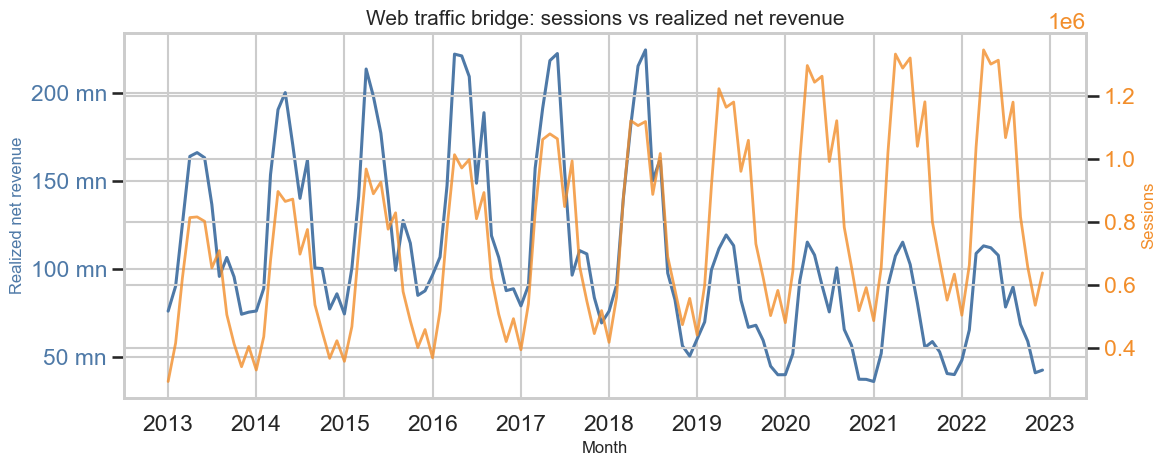

## Traffic bridge takeaways
- Sessions show a `0.44` correlation with realized net revenue at the monthly level, making them a useful leading indicator for demand monitoring.
- The strongest lag in the simple test is `1` days with a correlation of `0.31`.
- `email_campaign` has the lowest bounce rate in the sample, but the spread across sources is only `0.0001`; it should therefore be read as a **soft benchmark** for traffic quality.
- This section is retained as a descriptive-to-predictive bridge, not as a core action driver without direct diagnostic support.

In [10]:
traffic = raw["web_traffic"].copy()
traffic["date"] = pd.to_datetime(traffic["date"])
traffic["order_month"] = traffic["date"].dt.to_period("M").dt.to_timestamp()
traffic["pages_per_session"] = traffic["page_views"] / traffic["sessions"].replace(0, np.nan)

traffic_monthly = (
    traffic.groupby("order_month", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        avg_bounce=("bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean"),
        avg_pages_per_session=("pages_per_session", "mean"),
    )
)

traffic_kpi = monthly_kpis.merge(traffic_monthly, on="order_month", how="left")
corr_cols = [
    "gmv",
    "realized_net_revenue",
    "sessions",
    "unique_visitors",
    "avg_bounce",
    "avg_session_duration_sec",
    "avg_pages_per_session",
]
corr_table = traffic_kpi[corr_cols].corr()
display(corr_table)

source_perf = (
    traffic.groupby("traffic_source", as_index=False)
    .agg(
        total_sessions=("sessions", "sum"),
        avg_bounce=("bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean"),
        avg_pages_per_session=("pages_per_session", "mean"),
    )
    .sort_values(["avg_bounce", "avg_session_duration_sec"], ascending=[True, False])
)
display(source_perf.head(8))

lag_rows = []
daily_revenue = (
    fact_order.groupby("order_date", as_index=False)["realized_net_revenue"]
    .sum()
    .rename(columns={"order_date": "date"})
)
traffic_daily = traffic.groupby("date", as_index=False)["sessions"].sum()
for lag in [1, 7, 14, 30]:
    shifted = traffic_daily.copy()
    shifted["date"] = shifted["date"] + pd.Timedelta(days=lag)
    joined = daily_revenue.merge(shifted, on="date", how="inner")
    corr_val = joined["realized_net_revenue"].corr(joined["sessions"])
    lag_rows.append({"lag_days": lag, "corr_sessions_to_revenue": corr_val})
lag_corr_df = pd.DataFrame(lag_rows).sort_values("corr_sessions_to_revenue", ascending=False)
display(lag_corr_df)

bridge_plot = traffic_kpi[["order_month", "realized_net_revenue", "sessions"]].dropna().copy()
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(
    bridge_plot["order_month"],
    bridge_plot["realized_net_revenue"],
    color="#4E79A7",
    linewidth=2.2,
    label="Realized net revenue",
)
ax1.set_ylabel("Realized net revenue", color="#4E79A7")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _pos: f"{y/1e6:.0f} mn"))
ax1.tick_params(axis="y", labelcolor="#4E79A7")

ax2 = ax1.twinx()
ax2.plot(
    bridge_plot["order_month"],
    bridge_plot["sessions"],
    color="#F28E2B",
    linewidth=2,
    alpha=0.8,
    label="Sessions",
)
ax2.set_ylabel("Sessions", color="#F28E2B")
ax2.tick_params(axis="y", labelcolor="#F28E2B")
ax1.set_title("Web traffic bridge: sessions vs realized net revenue")
ax1.set_xlabel("Month")
plt.tight_layout()
plt.show()

best_lag = lag_corr_df.iloc[0]
best_source = source_perf.iloc[0]
bounce_spread = float(source_perf["avg_bounce"].max() - source_perf["avg_bounce"].min())
sessions_corr = corr_table.loc["realized_net_revenue", "sessions"]
display(
    Markdown(
        "## Traffic bridge takeaways\n"
        f"- Sessions show a `{sessions_corr:.2f}` correlation with realized net revenue at the monthly level, making them a useful leading indicator for demand monitoring.\n"
        f"- The strongest lag in the simple test is `{int(best_lag['lag_days'])}` days with a correlation of `{best_lag['corr_sessions_to_revenue']:.2f}`.\n"
        f"- `{best_source['traffic_source']}` has the lowest bounce rate in the sample, but the spread across sources is only `{bounce_spread:.4f}`; it should therefore be read as a **soft benchmark** for traffic quality.\n"
        "- This section is retained as a descriptive-to-predictive bridge, not as a core action driver without direct diagnostic support."
    )
)


## 4. Diagnostic Analysis - Why Did It Happen?

The main story keeps only the drivers that are strong enough to support decision-making: `payment friction`, `wrong-size return`, and `promotion erosion (proxy)`. Weaker signals are retained as caveats rather than being promoted into root causes.


,metric,value,note
0,Overall cancellation rate,0.0971,Cancellation rate across all resolved orders
1,cod cancellation rate,0.1692,Lift of 1.74x versus the baseline
2,cod vs non-cod gap,0.0847,"Bootstrap CI [8.2%, 8.7%]"
3,cod share of cancel leakage,0.2600,"Scope 91,443 orders"


,payment_method,orders,cancelled_orders,cancel_leakage_value,scope_value,avg_order_value,cancel_rate,rate_lift_vs_avg,share_of_cancel_leakage,priority_score
0,cod,91443,15468,"394,200,161.6100","2,322,894,981.6200","25,402.6550",0.1692,1.7419,0.2600,"686,656,330.0666"
1,credit_card,337332,28452,"726,926,951.6200","8,551,779,896.0600","25,351.2264",0.0843,0.8685,0.4795,"631,371,482.8589"
2,paypal,91847,7817,"199,499,370.8000","2,345,999,928.9900","25,542.4775",0.0851,0.8764,0.1316,"174,845,958.8445"
3,apple_pay,61295,5190,"130,729,151.3900","1,550,864,341.6200","25,301.6452",0.0847,0.8719,0.0862,"113,986,569.3211"
4,bank_transfer,30403,2535,"64,535,370.7700","768,986,250.2400","25,293.1043",0.0834,0.8586,0.0426,"55,411,290.6553"


,payment_method,order_source,orders,cancelled_orders,cancel_leakage_value,scope_value,cancel_rate,method_cancel_rate,rate_gap_vs_method,share_of_method_orders
0,credit_card,organic_search,94664,8016,"205,714,252.1400","2,396,609,182.2400",0.0847,0.0843,0.0003,0.2806
1,credit_card,paid_search,73595,6161,"156,136,498.9900","1,867,194,694.6600",0.0837,0.0843,-0.0006,0.2182
2,credit_card,social_media,67517,5719,"148,479,318.4100","1,711,763,503.5700",0.0847,0.0843,0.0004,0.2002
3,cod,organic_search,25431,4334,"109,393,160.8400","646,669,992.6100",0.1704,0.1692,0.0013,0.2781
4,cod,paid_search,20100,3377,"87,985,528.5000","512,057,251.9400",0.1680,0.1692,-0.0011,0.2198
5,credit_card,email_campaign,40644,3391,"85,965,244.7500","1,031,862,584.5800",0.0834,0.0843,-0.0009,0.1205
6,cod,social_media,18530,3037,"75,997,758.0100","468,166,307.1200",0.1639,0.1692,-0.0053,0.2026
7,credit_card,referral,33909,2901,"72,440,847.7800","857,944,163.4500",0.0856,0.0843,0.0012,0.1005


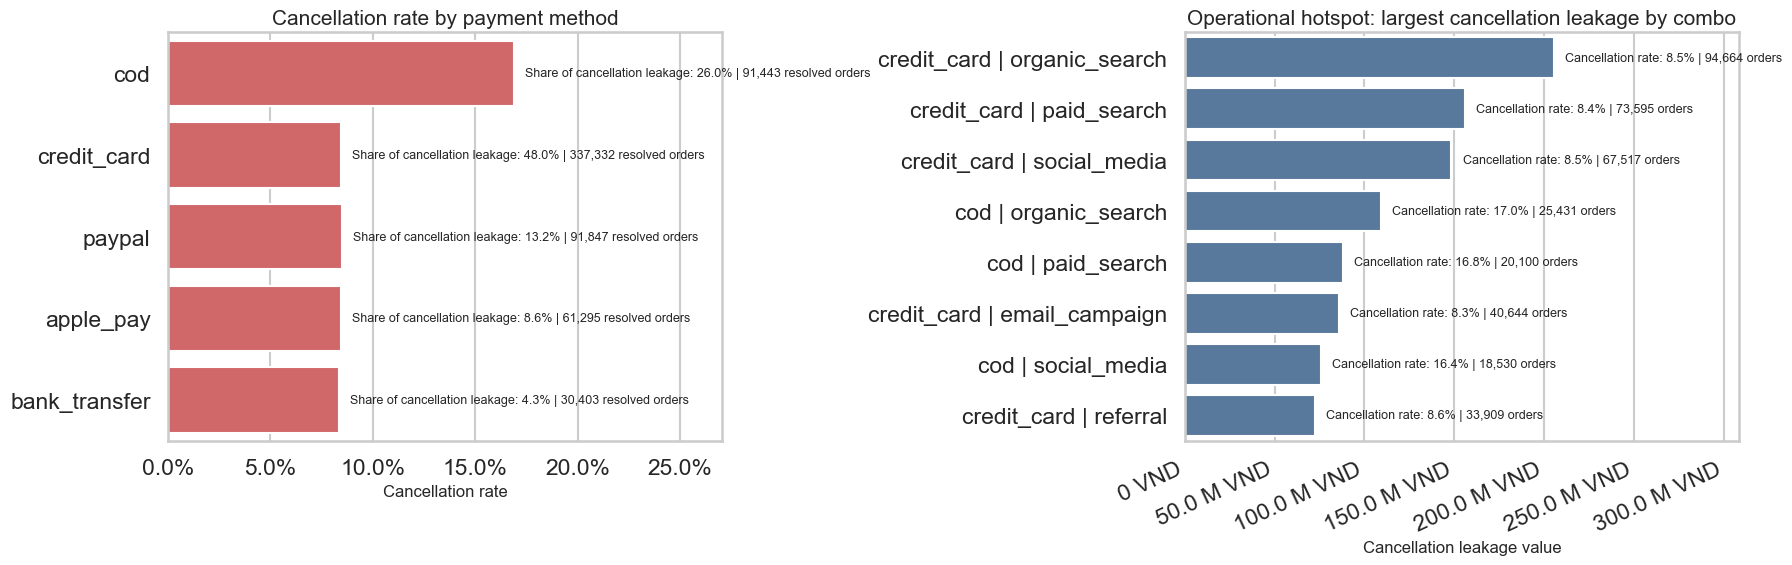

## Diagnostic 1 - Cancellation friction
- On the **full-history resolved sample**, `COD` posts a cancellation rate of `16.9%`, or `1.74x` the baseline, and represents `26.0%` of cancellation leakage.
- The first operational hotspot to monitor is `cod x organic_search`, because this bucket holds `25,431` orders and `109.4` mn VND of leakage.
- Action implication: prioritize checkout and CRM friction reduction for the highest-risk payment method; the prescriptive section below sizes upside on the `2022` scope to avoid overstating benefit.

In [11]:
cancel_methods, cancel_combos, cancel_metrics = eda.build_cancellation_story(fact_order)
display(cancel_metrics)
display(cancel_methods.head(8))
display(cancel_combos.head(8))
eda.plot_cancellation_story(cancel_methods, cancel_combos)

top_cancel = cancel_methods.iloc[0]
hotspot_combo = (
    cancel_combos.loc[cancel_combos["payment_method"].eq(top_cancel["payment_method"])]
    .sort_values("cancel_leakage_value", ascending=False)
    .iloc[0]
)
display(
    Markdown(
        "## Diagnostic 1 - Cancellation friction\n"
        f"- On the **full-history resolved sample**, `{str(top_cancel['payment_method']).upper()}` posts a cancellation rate of `{top_cancel['cancel_rate']:.1%}`, or `{top_cancel['rate_lift_vs_avg']:.2f}x` the baseline, and represents `{top_cancel['share_of_cancel_leakage']:.1%}` of cancellation leakage.\n"
        f"- The first operational hotspot to monitor is `{hotspot_combo['payment_method']} x {hotspot_combo['order_source']}`, because this bucket holds `{hotspot_combo['orders']:,}` orders and `{hotspot_combo['cancel_leakage_value']/1e6:.1f}` mn VND of leakage.\n"
        f"- Action implication: prioritize checkout and CRM friction reduction for the highest-risk payment method; the prescriptive section below sizes upside on the `{recent_year}` scope to avoid overstating benefit."
    )
)


,category,size,order_lines,wrong_size_returns,wrong_size_refund_value,wrong_size_rate,peer_order_lines,peer_wrong_size_returns,peer_wrong_size_rate,rate_gap_vs_category_peer,peer_gap_pvalue,share_of_wrong_size_refund,bucket
0,Streetwear,XL,121243,2319,"47,191,819.3700",0.0191,271273,5307,0.0196,-0.0004,0.3666,0.2670,Streetwear | size XL
1,Streetwear,S,95073,1858,"32,449,294.5100",0.0195,297443,5768,0.0194,0.0002,0.7795,0.1836,Streetwear | size S
2,Streetwear,M,87602,1730,"30,620,865.7400",0.0197,304914,5896,0.0193,0.0004,0.4446,0.1732,Streetwear | size M
3,Streetwear,L,88598,1719,"30,149,470.2500",0.0194,303918,5907,0.0194,-0.0000,0.9597,0.1706,Streetwear | size L
4,Outdoor,L,71868,1457,"7,348,076.3900",0.0203,187451,3697,0.0197,0.0006,0.3768,0.0416,Outdoor | size L
5,Outdoor,M,70743,1383,"7,295,363.9500",0.0195,188576,3771,0.0200,-0.0004,0.4767,0.0413,Outdoor | size M
6,Outdoor,XL,61233,1190,"6,550,242.0600",0.0194,198086,3964,0.0200,-0.0006,0.3797,0.0371,Outdoor | size XL
7,Outdoor,S,55475,1124,"6,162,237.6900",0.0203,203844,4030,0.0198,0.0005,0.4728,0.0349,Outdoor | size S
8,Casual,S,8217,157,"1,713,040.6400",0.0191,15770,297,0.0188,0.0003,0.9223,0.0097,Casual | size S
9,GenZ,M,10266,226,"1,404,316.4900",0.0220,26857,508,0.0189,0.0031,0.0605,0.0079,GenZ | size M


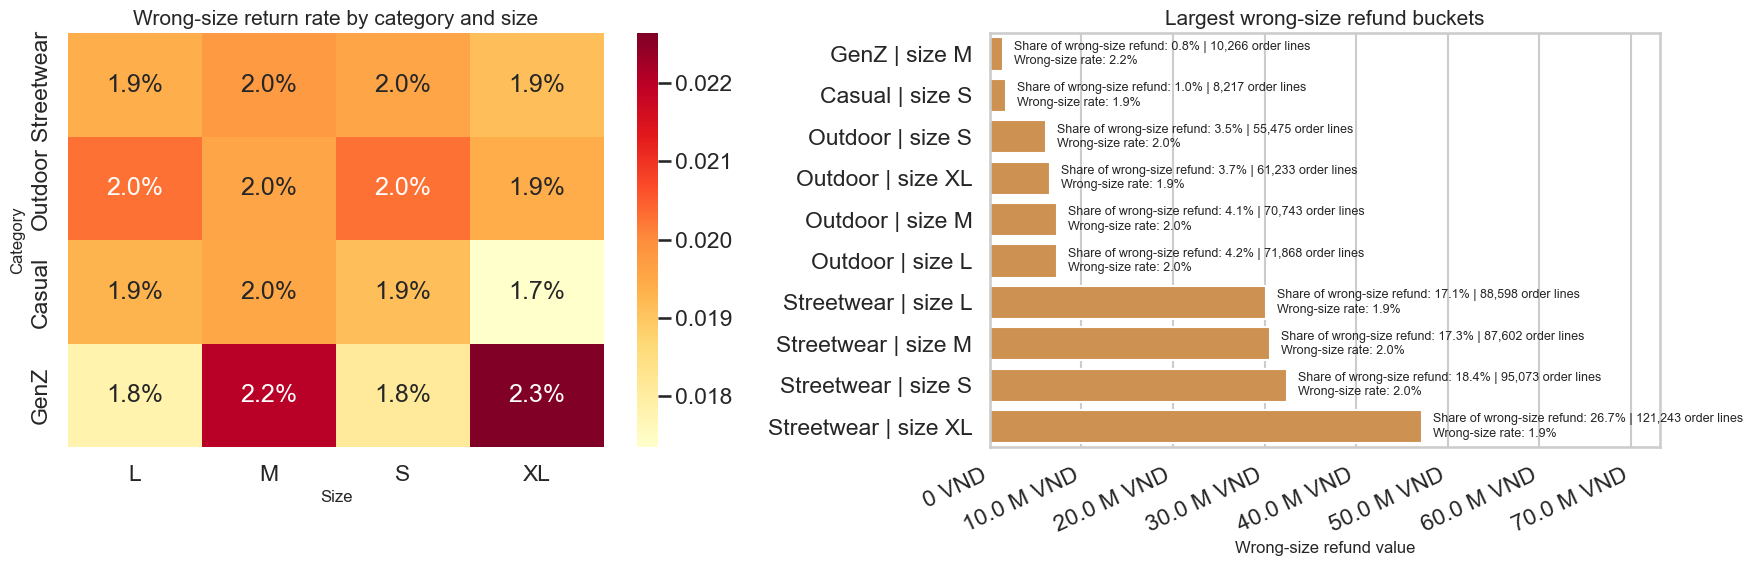

## Diagnostic 2 - Wrong-size return
- On the **full-history order-line sample**, the heaviest bucket is `Streetwear | size XL` with a wrong-size rate of `1.9%` across `121,243` order lines.
- Relative to other sizes in the same category, this bucket sits close to its peer group (`gap -0.0%`, p-value `0.3666`); this is therefore more of a **scale problem** than an anomaly-rate problem.
- This bucket alone represents `26.7%` of wrong-size refund value, or `47.2` mn VND, making it the most practical place to run the first pilot.
- Action implication: prioritize fit guidance, an exchange-first flow, and sizing content for the largest bucket first; the action section below sizes impact only on the `2022` scope.

In [12]:
size_pivot, size_ranking = eda.build_size_story(fact_line)
display(size_ranking.head(12))
eda.plot_size_story(size_pivot, size_ranking)

top_size = size_ranking.iloc[0]
display(
    Markdown(
        "## Diagnostic 2 - Wrong-size return\n"
        f"- On the **full-history order-line sample**, the heaviest bucket is `{top_size['bucket']}` with a wrong-size rate of `{top_size['wrong_size_rate']:.1%}` across `{int(top_size['order_lines']):,}` order lines.\n"
        f"- Relative to other sizes in the same category, this bucket sits close to its peer group (`gap {top_size['rate_gap_vs_category_peer']:.1%}`, p-value `{top_size['peer_gap_pvalue']:.4f}`); this is therefore more of a **scale problem** than an anomaly-rate problem.\n"
        f"- This bucket alone represents `{top_size['share_of_wrong_size_refund']:.1%}` of wrong-size refund value, or `{top_size['wrong_size_refund_value']/1e6:.1f}` mn VND, making it the most practical place to run the first pilot.\n"
        f"- Action implication: prioritize fit guidance, an exchange-first flow, and sizing content for the largest bucket first; the action section below sizes impact only on the `{recent_year}` scope."
    )
)


,dominant_category,order_source,months_observed,paired_months,promo_orders,control_orders,negative_margin_months,negative_month_share,avg_discount_rate_promo,median_margin_delta,weighted_margin_delta,weighted_net_delta,weighted_leakage_delta,erosion_value_proxy,sign_test_pvalue,recent_year,recent_year_months,recent_year_promo_orders,recent_year_control_orders,recent_year_negative_margin_months,recent_year_negative_share,recent_year_weighted_margin_delta,recent_year_erosion_value_proxy,recent_year_sign_test_pvalue,is_core_story
0,Streetwear,organic_search,63,63,28251,30318,63,1.0000,0.1158,"-5,802.0918","-5,890.2236","-5,311.8380",-0.0050,"166,404,708.3029",0.0000,2022,7,1890,1896,7,1.0000,"-7,099.8377","13,418,693.2031",0.0078,True
1,Streetwear,paid_search,59,59,22056,22510,59,1.0000,0.1152,"-5,861.6465","-5,807.2480","-5,405.1782",0.0016,"128,084,661.8435",0.0000,2022,6,1393,1306,6,1.0000,"-5,616.0495","7,823,156.9171",0.0156,True
2,Streetwear,social_media,57,57,19585,20382,57,1.0000,0.1157,"-5,955.9166","-5,933.3914","-5,749.7578",0.0042,"116,205,470.4576",0.0000,2022,5,1024,1227,5,1.0000,"-6,457.8222","6,612,809.9771",0.0312,True
3,Streetwear,referral,51,51,8346,9715,51,1.0000,0.1283,"-5,929.6851","-5,510.6274","-5,240.9698",0.0061,"45,991,696.3608",0.0000,2022,5,524,602,5,1.0000,"-7,784.5165","4,079,086.6411",0.0312,True
4,Streetwear,email_campaign,54,54,10901,12107,54,1.0000,0.1222,"-5,467.7446","-5,524.2232","-5,324.6294",-0.0020,"60,219,557.5409",0.0000,2022,5,644,708,5,1.0000,"-5,810.1677","3,741,748.0228",0.0312,True
5,Streetwear,direct,49,49,6535,7691,49,1.0000,0.1291,"-5,640.4363","-5,539.7300","-4,736.2740",-0.0012,"36,202,135.6602",0.0000,2022,5,413,429,5,1.0000,"-6,414.5811","2,649,221.9746",0.0312,True
6,Outdoor,organic_search,61,61,12166,13569,61,1.0000,0.1259,"-2,131.4820","-1,947.0797","-1,985.4164",-0.0006,"23,688,171.1471",0.0000,2022,5,377,389,5,1.0000,"-2,067.4003","779,409.9286",0.0312,True
7,Outdoor,social_media,55,55,8107,8796,55,1.0000,0.1279,"-2,198.4564","-2,081.5097","-2,200.0534",0.0029,"16,874,799.0010",0.0000,2022,5,260,295,5,1.0000,"-2,616.2144","680,215.7490",0.0312,True
8,Outdoor,paid_search,57,57,9236,9804,57,1.0000,0.1258,"-1,853.0562","-1,919.8659","-1,972.8388",-0.0115,"17,731,881.0481",0.0000,2022,4,233,227,4,1.0000,"-1,990.3912","463,761.1490",0.0625,True
9,Outdoor,email_campaign,44,44,4212,4705,44,1.0000,0.1304,"-2,255.9821","-2,156.5096","-2,666.6336",-0.0049,"9,083,218.5207",0.0000,2022,3,116,114,3,1.0000,"-2,647.8527","307,150.9147",0.1250,True


,order_month,dominant_category,order_source,avg_discount_rate_no_promo,avg_discount_rate_promo,avg_margin_no_promo,avg_margin_promo,avg_net_no_promo,avg_net_promo,leakage_rate_no_promo,leakage_rate_promo,orders_no_promo,orders_promo,net_delta,margin_delta,leakage_delta,bucket_weight
0,2013-08-01,Streetwear,paid_search,0.0000,0.0171,"6,474.5544","-11,304.2830","31,522.1446","15,030.8244",0.0811,0.1647,37.0000,911.0000,"-16,491.3202","-17,778.8374",0.0836,948.0000
1,2015-08-01,Streetwear,social_media,0.0000,0.0172,"5,999.8244","-11,111.3318","30,484.4746","14,917.0326",0.0714,0.1609,28.0000,839.0000,"-15,567.4420","-17,111.1562",0.0895,867.0000
2,2015-08-01,Streetwear,paid_search,0.0000,0.0178,"6,230.2870","-10,868.1368","26,427.7629","15,029.5037",0.0488,0.1681,41.0000,"1,017.0000","-11,398.2592","-17,098.4239",0.1194,"1,058.0000"
3,2013-08-01,Streetwear,organic_search,0.0000,0.0164,"6,425.8179","-10,665.4712","28,980.6237","14,733.2180",0.2321,0.1657,56.0000,"1,153.0000","-14,247.4058","-17,091.2891",-0.0665,"1,209.0000"
4,2013-08-01,Streetwear,social_media,0.0000,0.0169,"5,968.8282","-10,950.7843","36,728.6431","15,521.3422",0.0000,0.1566,35.0000,862.0000,"-21,207.3009","-16,919.6125",0.1566,897.0000
5,2013-08-01,Streetwear,email_campaign,0.0000,0.0178,"4,250.4735","-10,537.4003","26,101.8515","13,781.3981",0.1923,0.1520,26.0000,454.0000,"-12,320.4534","-14,787.8739",-0.0403,480.0000
6,2015-08-01,Streetwear,organic_search,0.0000,0.0169,"3,291.6220","-11,026.3482","28,369.7178","15,189.0532",0.2400,0.1597,50.0000,"1,221.0000","-13,180.6646","-14,317.9702",-0.0803,"1,271.0000"
7,2022-06-01,Streetwear,referral,0.0000,0.1525,"7,409.7300","-4,473.9569","39,917.4731","29,846.0646",0.1152,0.1731,217.0000,52.0000,"-10,071.4085","-11,883.6869",0.0579,269.0000
8,2018-01-01,Streetwear,organic_search,0.0000,0.1667,"6,166.0747","-5,631.3251","34,247.2836","26,839.2811",0.1369,0.1852,431.0000,27.0000,"-7,408.0025","-11,797.3998",0.0483,458.0000
9,2022-01-01,Streetwear,organic_search,0.0000,0.1667,"6,258.6618","-5,516.8457","39,655.1089","32,631.5742",0.1660,0.1923,247.0000,26.0000,"-7,023.5347","-11,775.5075",0.0263,273.0000


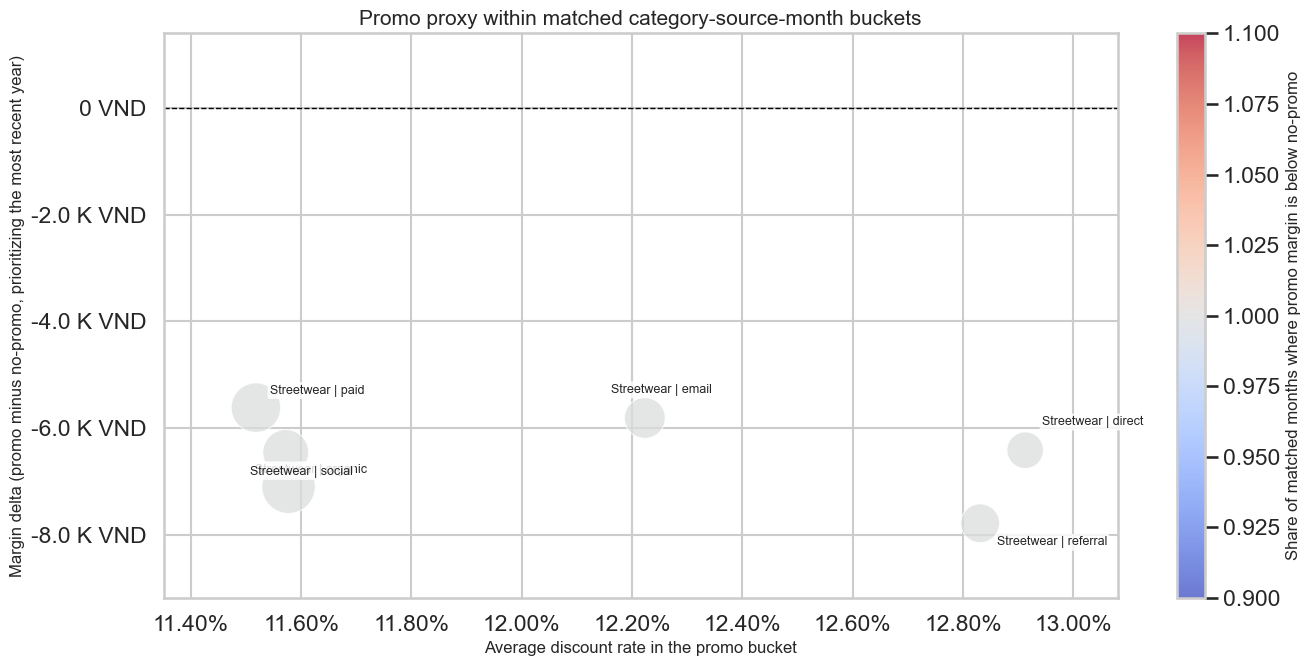

## Diagnostic 3 - Promotion erosion (proxy)
- In **matched monthly comparisons within the same `category x source`**, the clearest bucket is `Streetwear x organic_search` with a margin delta of `-7.1` k VND on the `2022` scope.
- This bucket has `1,890` promo orders in `2022`; across full history, the negative signal repeats in `100%` of matched months, median margin delta remains negative at `-5.8` k VND, and the sign test yields a p-value of `0.007812`.
- Action implication: this is a **proxy signal that is stable enough to justify a bucket-level guardrail pilot**, but it should not be interpreted as causal proof for broad promo cuts.

In [13]:
promo_summary, promo_monthly = eda.build_promo_story(fact_order)
display(promo_summary.head(12))
display(promo_monthly.head(12))
eda.plot_promo_story(promo_summary)

promo_core = promo_summary.loc[promo_summary["is_core_story"]].head(1)
if promo_core.empty:
    promo_core = promo_summary.head(1)
promo_core = promo_core.iloc[0]

promo_recent_margin = (
    promo_core["recent_year_weighted_margin_delta"]
    if pd.notna(promo_core.get("recent_year_weighted_margin_delta"))
    else promo_core["weighted_margin_delta"]
)
promo_recent_orders = int(
    promo_core["recent_year_promo_orders"] if promo_core.get("recent_year_promo_orders", 0) else promo_core["promo_orders"]
)
promo_recent_year = int(promo_core["recent_year"]) if pd.notna(promo_core.get("recent_year")) else recent_year
promo_sign_test = (
    promo_core["recent_year_sign_test_pvalue"]
    if pd.notna(promo_core.get("recent_year_sign_test_pvalue"))
    else promo_core["sign_test_pvalue"]
)

display(
    Markdown(
        "## Diagnostic 3 - Promotion erosion (proxy)\n"
        f"- In **matched monthly comparisons within the same `category x source`**, the clearest bucket is `{promo_core['dominant_category']} x {promo_core['order_source']}` with a margin delta of `{promo_recent_margin/1e3:.1f}` k VND on the `{promo_recent_year}` scope.\n"
        f"- This bucket has `{promo_recent_orders:,}` promo orders in `{promo_recent_year}`; across full history, the negative signal repeats in `{promo_core['negative_month_share']:.0%}` of matched months, median margin delta remains negative at `{promo_core['median_margin_delta']/1e3:.1f}` k VND, and the sign test yields a p-value of `{promo_sign_test:.4g}`.\n"
        "- Action implication: this is a **proxy signal that is stable enough to justify a bucket-level guardrail pilot**, but it should not be interpreted as causal proof for broad promo cuts."
    )
)


In [14]:
root_cause_df = eda.build_story_root_causes(cancel_methods, size_ranking, promo_summary)
excluded_driver_df = eda.build_excluded_driver_appendix(fact_order, raw["inventory"])
display(root_cause_df)

root_md = "## Root-cause synthesis\n" + "\n".join(
    [
        f"- **{row.driver}**: {row.quant_signal}. {row.evidence}. Implication: {row.action_hint}."
        for row in root_cause_df.itertuples(index=False)
    ]
)
root_md += (
    f"\n\n**Scope control:** The three drivers above are identified from the full-history resolved sample to improve signal stability; "
    f"the prescriptive section sizes opportunity on the `{recent_year}` scope."
)
display(Markdown(root_md))

display(
    Markdown(
        "## Appendix check - Why delivery and stockout were excluded from the main story\n"
        "- Both signals were reviewed to avoid missing an operational root cause, but they remain in the appendix because the evidence is not strong enough to place them in the highest-priority action set."
    )
)
display(excluded_driver_df)


,driver,quant_signal,evidence,action_hint
0,Cancellation friction,cod posts a cancellation rate of 16.9% and acc...,"Full-history resolved sample | scope 91,443 or...",Reduce checkout and CRM friction for the highe...
1,Wrong-size return,Streetwear | size XL shows a wrong-size rate o...,Full-history order-line sample | refund 47.19 ...,Strengthen size guidance and prioritize an exc...
2,Promotion erosion (proxy),Matched monthly comparisons within the same ca...,Full-history 63 matched months | year 2022 sco...,Pilot bucket-level promo guardrails instead of...


## Root-cause synthesis
- **Cancellation friction**: cod posts a cancellation rate of 16.9% and accounts for 26.0% of cancellation leakage. Full-history resolved sample | scope 91,443 orders | leakage 394.20 M VND. Implication: Reduce checkout and CRM friction for the highest-risk payment method.
- **Wrong-size return**: Streetwear | size XL shows a wrong-size rate of 1.9% and represents 26.7% of wrong-size refund value. Full-history order-line sample | refund 47.19 M VND across 121,243 order lines. Implication: Strengthen size guidance and prioritize an exchange-first flow for the largest bucket.
- **Promotion erosion (proxy)**: Matched monthly comparisons within the same category and source show that Streetwear | organic_search has a proxy margin delta of -7.1 K VND. Full-history 63 matched months | year 2022 scope 1,890 promo orders | negative months 100%. Implication: Pilot bucket-level promo guardrails instead of broad-based promo cuts.

**Scope control:** The three drivers above are identified from the full-history resolved sample to improve signal stability; the prescriptive section sizes opportunity on the `2022` scope.

## Appendix check - Why delivery and stockout were excluded from the main story
- Both signals were reviewed to avoid missing an operational root cause, but they remain in the appendix because the evidence is not strong enough to place them in the highest-priority action set.

,driver_checked,headline,evidence,decision
0,Delivery delay,Best threshold test at >4 days produced a gap ...,"CI [-0.2%, 0.1%] | Mann-Whitney p=0.054",Kept in the appendix because the CI touches ze...
1,Stockout pressure,"corr(stockout_rate, leakage_rate) = 0.081","corr(fill_rate, realized_net_revenue) = -0.159...",Kept in the appendix because the correlation i...


## 5. Predictive Analysis - What May Happen Next?

The purpose of the predictive section is not to ?beat the business? with a model that looks elegant on paper. The real question is more practical: **if only about 15% of orders can be reviewed, which queue should be prioritized first?**


In [15]:
model_df, numeric_features, categorical_features = eda.build_model_dataset(fact_order)
splits = eda.split_model_data(model_df)

split_summary = pd.DataFrame(
    [
        {
            "split": name,
            "rows": len(df),
            "positive_rate": df["target"].mean(),
            "start_date": df["order_date"].min(),
            "end_date": df["order_date"].max(),
        }
        for name, df in splits.items()
    ]
)

train_end = splits["train"]["order_date"].max()
valid_start = splits["valid"]["order_date"].min()
valid_end = splits["valid"]["order_date"].max()
test_start = splits["test"]["order_date"].min()

assert train_end < valid_start, "Train and validation windows overlap in time"
assert valid_end < test_start, "Validation and test windows overlap in time"

leakage_guard_df = pd.DataFrame(
    [
        {
            "check": "train_end < valid_start",
            "status": bool(train_end < valid_start),
            "value": f"{train_end.date()} < {valid_start.date()}",
        },
        {
            "check": "valid_end < test_start",
            "status": bool(valid_end < test_start),
            "value": f"{valid_end.date()} < {test_start.date()}",
        },
    ]
)

history_cols = ["prior_total_orders", "prior_resolved_orders", "prior_leakage_orders"]
history_check = model_df[history_cols].describe(percentiles=[0.5, 0.9, 0.99]).T

display(split_summary)
display(leakage_guard_df)
display(history_check)
print(f"Number of numeric features: {len(numeric_features)}")
print(f"Number of categorical features: {len(categorical_features)}")


,split,rows,positive_rate,start_date,end_date
0,train,547418,0.1555,2012-07-04,2020-12-31
1,valid,31808,0.1593,2021-01-01,2021-12-31
2,test,33094,0.1634,2022-01-01,2022-12-31


,check,status,value
0,train_end < valid_start,True,2020-12-31 < 2021-01-01
1,valid_end < test_start,True,2021-12-31 < 2022-01-01


,count,mean,std,min,50%,90%,99%,max
prior_total_orders,"612,320.0000",8.2561,9.6148,0.0000,5.0000,20.0000,45.0000,106.0000
prior_resolved_orders,"612,320.0000",7.8389,9.1547,0.0000,5.0000,19.0000,42.0000,103.0000
prior_leakage_orders,"612,320.0000",1.2151,1.7407,0.0000,1.0000,3.0000,8.0000,26.0000


Number of numeric features: 23
Number of categorical features: 14


In [16]:
modeling_result = eda.fit_models(splits, numeric_features, categorical_features)
review_queue_df = eda.build_review_queue_summary(modeling_result)
model_interpretation_df = eda.build_model_interpretation(modeling_result)

primary_model = modeling_result["primary_model"]
primary_metrics = modeling_result["metrics"].loc[
    modeling_result["metrics"]["model"].eq(primary_model)
].iloc[0]

display(modeling_result["metrics"])
display(review_queue_df)
display(model_interpretation_df)
print(
    f"Selected triage model = {primary_model} | threshold = {modeling_result['threshold']:.4f} | "
    f"review share ~ {primary_metrics['review_share']:.1%}"
)


,model,roc_auc,pr_auc,brier,precision_at_threshold,recall_at_threshold,review_share,lift_at_10pct,lift_at_15pct,captured_leakage_value_share,captured_leakage_value
0,LogisticRegression,0.5581,0.2067,0.2430,0.2700,0.2423,0.1466,1.6423,1.6423,0.2470,"35,401,610.6200"
1,DecisionTree,0.5508,0.1958,0.2431,0.2307,0.2146,0.1519,1.5406,1.4192,0.2278,"32,640,552.7900"
2,BusinessRule,0.5515,0.1894,0.1901,0.2089,0.1870,0.1462,1.3205,1.2761,0.1765,"25,300,396.6000"


,model,selected_orders,review_share,queue_leakage_rate,queue_scope_value,queue_leakage_value,captured_leakage_value_share
0,LogisticRegression,4852,0.1466,0.2700,"155,879,547.0900","35,401,610.6200",0.2470
1,DecisionTree,5028,0.1519,0.2307,"178,533,843.8100","32,640,552.7900",0.2278
2,BusinessRule,4839,0.1462,0.2089,"148,406,459.9500","25,300,396.6000",0.1765


,feature,coefficient,direction
57,payment method cod,0.6513,risk up
58,payment method credit card,-0.1636,risk down
59,payment method paypal,-0.1621,risk down
56,payment method bank transfer,-0.1611,risk down
55,payment method apple pay,-0.1602,risk down
100,order month name January,-0.0253,risk down
49,category size bucket Outdoor | S,0.0218,risk up
101,order month name July,0.0208,risk up
67,order source referral,0.0166,risk up
32,dominant segment Premium,0.0162,risk up


Selected triage model = LogisticRegression | threshold = 0.6444 | review share ~ 14.7%


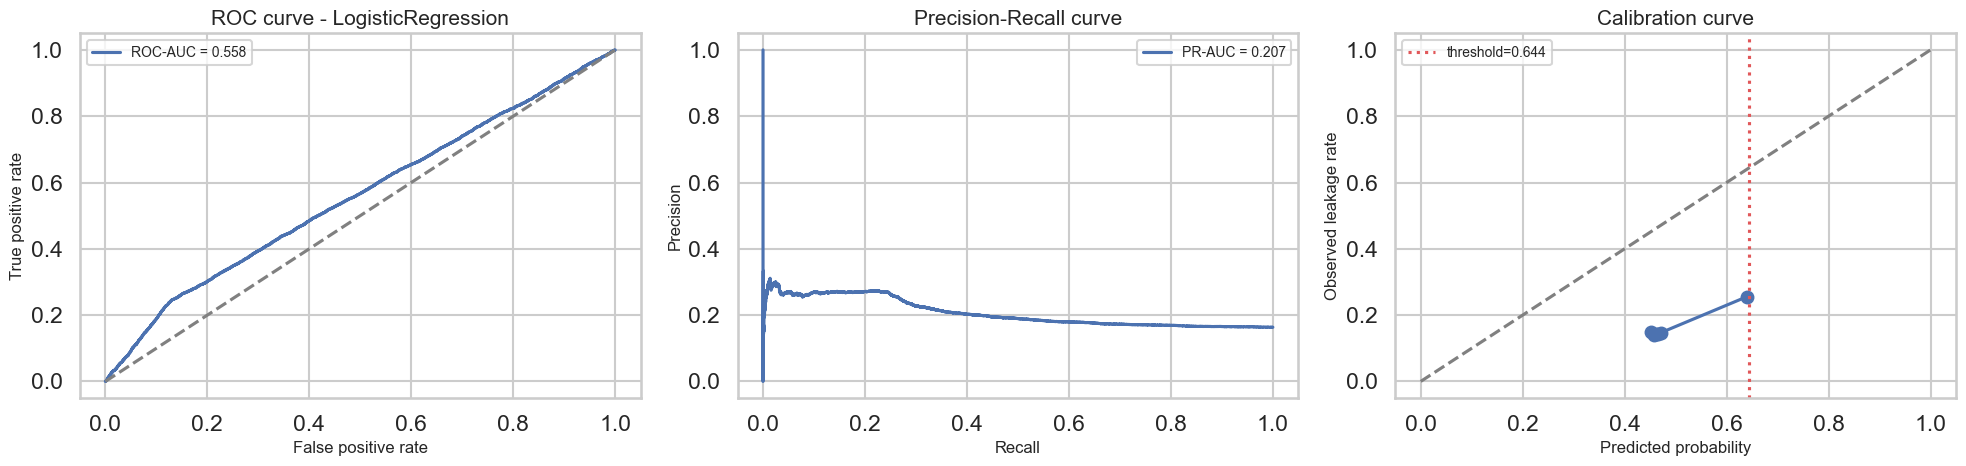

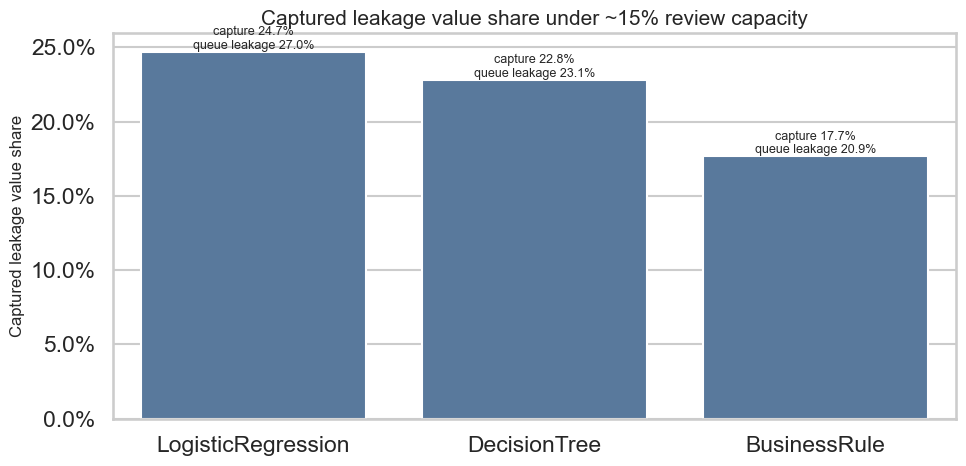

,risk_segment,orders,leakage_rate,avg_score,realized_net_revenue,leakage_value
0,high,4964,0.2683,0.6577,"123,610,826.6700","35,919,907.5300"
2,medium,6619,0.1475,0.4713,"198,565,493.8600","26,826,727.3800"
1,low,21511,0.1440,0.4590,"611,451,245.1400","80,561,547.1800"


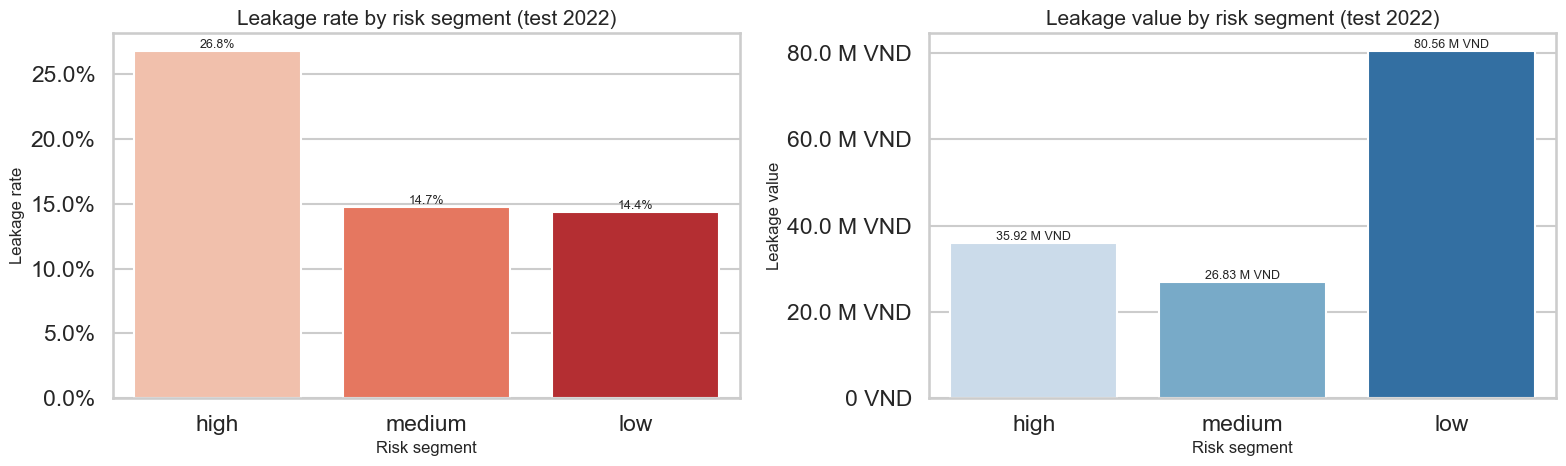

In [17]:
eda.plot_model_diagnostics(modeling_result)
eda.plot_review_capture(review_queue_df)

segment_df = eda.build_risk_segments(modeling_result)
display(segment_df)
eda.plot_risk_segments(segment_df)


In [18]:
primary_metrics = modeling_result["metrics"].iloc[0]
runner_up_metrics = modeling_result["metrics"].iloc[1]
rule_metrics = modeling_result["metrics"].loc[
    modeling_result["metrics"]["model"].eq("BusinessRule")
].iloc[0]

high_segment = segment_df.loc[segment_df["risk_segment"].eq("high")].iloc[0]
low_segment = segment_df.loc[segment_df["risk_segment"].eq("low")].iloc[0]
queue_headline = review_queue_df.iloc[0]

predictive_md = f"""
## Predictive takeaways
- Under a review capacity of roughly `{queue_headline['review_share']:.1%}` of orders, **{primary_metrics['model']}** captures `{primary_metrics['captured_leakage_value_share']:.1%}` of leakage value, slightly ahead of `{runner_up_metrics['model']}` at `{runner_up_metrics['captured_leakage_value_share']:.1%}`, but not by a dramatic margin.
- Versus the `BusinessRule` baseline, the lead model still performs better on `captured leakage value share` (`{primary_metrics['captured_leakage_value_share']:.1%}` vs `{rule_metrics['captured_leakage_value_share']:.1%}`), which is enough to justify using it as an additional triage layer.
- The `high-risk` segment posts a leakage rate of `{high_segment['leakage_rate']:.1%}`; however, the `low-risk` segment still carries `{low_segment['leakage_value']/1e6:.1f}` mn VND of leakage because its volume is much larger. The queue is therefore designed to **prioritize review order under capacity constraints**, not to ignore the remaining buckets.
- Feature interpretation shows that `payment method COD` remains the strongest risk-up signal, which aligns cleanly with the cancellation diagnostic story.
"""
display(Markdown(predictive_md))



## Predictive takeaways
- Under a review capacity of roughly `14.7%` of orders, **LogisticRegression** captures `24.7%` of leakage value, slightly ahead of `DecisionTree` at `22.8%`, but not by a dramatic margin.
- Versus the `BusinessRule` baseline, the lead model still performs better on `captured leakage value share` (`24.7%` vs `17.7%`), which is enough to justify using it as an additional triage layer.
- The `high-risk` segment posts a leakage rate of `26.8%`; however, the `low-risk` segment still carries `80.6` mn VND of leakage because its volume is much larger. The queue is therefore designed to **prioritize review order under capacity constraints**, not to ignore the remaining buckets.
- Feature interpretation shows that `payment method COD` remains the strongest risk-up signal, which aligns cleanly with the cancellation diagnostic story.


## 6. Prescriptive Analysis - What Should We Do?

The action plan below keeps only the four interventions that are easiest to defend in front of judges. Each action links directly to evidence from the diagnostic or predictive sections and is quantified using `scope` plus `recoverable leakage value`.


In [19]:
action_df = eda.build_action_plan(
    fact_order=fact_order,
    cancel_methods=cancel_methods,
    size_ranking=size_ranking,
    promo_summary=promo_summary,
    review_queue_df=review_queue_df,
)
roi_df = eda.simulate_action_roi(action_df)

print("Action library")
display(action_df)
print("Scenario table")
display(roi_df)


Action library


,action,driver,owner,kpi,scope_orders,scope_value,current_leakage_value,recoverable_low_value,recoverable_base_value,recoverable_high_value,monthly_upside_base,effort,timeline,assumption,evidence,priority_rank,priority_note,trade_off,share_of_year_leakage,share_of_scope_leakage
0,Reduce COD and checkout friction,Cancellation friction,Checkout + CRM,Cancellation rate of the hotspot payment method,4920,"158,578,086.8400","27,796,069.9800","2,223,685.5984","4,169,410.4970","6,115,135.3956","347,450.8747",2.0000,30 days: remove checkout pain points; 60 days:...,Recovery range of 8%-15%-22% on the bucket's c...,Year 2022: cod cancellation rate 17.3% | share...,1,Priority 1: strongest evidence with low execut...,This action can materially reduce cancellation...,0.0291,0.1500
1,Strengthen size guidance and exchange flow,Wrong-size return,Merchandising + CX,Wrong-size refund value and wrong-size rate,6365,"265,627,312.3800","8,699,289.8800","1,304,893.4820","2,174,822.4700","3,044,751.4580","181,235.2058",2.5000,30 days: refine fit guidance; 60 days: launch ...,Recovery range of 15%-25%-35% on the bucket's ...,Year 2022: Streetwear | size XL wrong-size rat...,2,Priority 2: clear bucket definition with a cle...,This is lower-risk to revenue than a promo int...,0.0152,0.2500
2,Run a high-risk review queue,Predictive triage,Ops + Risk,Captured leakage value share within the top re...,4852,"155,879,547.0900","35,401,610.6200","1,770,080.5310","3,186,144.9558","4,956,225.4868","265,512.0797",3.2000,30 days: pilot manual review; 60 days: formali...,Recovery range of 5%-9%-14% on the bucket's cu...,LogisticRegression captures 24.7% of leakage v...,3,Priority 3: best fit when review capacity is l...,"Targeting improves, but the business pays for ...",0.0222,0.0900
3,Pilot promo guardrails by bucket,Promotion erosion (proxy),Growth + Finance,Weighted margin delta promo vs no-promo,2163,"79,720,732.0800","15,356,948.8880","1,842,833.8666","3,071,389.7776","4,299,945.6886","255,949.1481",2.9000,30 days: freeze the weakest pilot bucket; 60 d...,Recovery range of 12%-20%-28% on the bucket's ...,Year 2022: Streetwear | organic_search margin ...,4,Priority 4: execute as a controlled pilot beca...,"The weakest buckets show clear margin upside, ...",0.0214,0.2000


Scenario table


,action,scenario,owner,kpi,recoverable_value,monthly_upside
0,Reduce COD and checkout friction,Conservative,Checkout + CRM,Cancellation rate of the hotspot payment method,"2,223,685.5984","185,307.1332"
1,Reduce COD and checkout friction,Base,Checkout + CRM,Cancellation rate of the hotspot payment method,"4,169,410.4970","347,450.8747"
2,Reduce COD and checkout friction,Aggressive,Checkout + CRM,Cancellation rate of the hotspot payment method,"6,115,135.3956","509,594.6163"
3,Strengthen size guidance and exchange flow,Conservative,Merchandising + CX,Wrong-size refund value and wrong-size rate,"1,304,893.4820","108,741.1235"
4,Strengthen size guidance and exchange flow,Base,Merchandising + CX,Wrong-size refund value and wrong-size rate,"2,174,822.4700","181,235.2058"
5,Strengthen size guidance and exchange flow,Aggressive,Merchandising + CX,Wrong-size refund value and wrong-size rate,"3,044,751.4580","253,729.2882"
6,Run a high-risk review queue,Conservative,Ops + Risk,Captured leakage value share within the top re...,"1,770,080.5310","147,506.7109"
7,Run a high-risk review queue,Base,Ops + Risk,Captured leakage value share within the top re...,"3,186,144.9558","265,512.0797"
8,Run a high-risk review queue,Aggressive,Ops + Risk,Captured leakage value share within the top re...,"4,956,225.4868","413,018.7906"
9,Pilot promo guardrails by bucket,Conservative,Growth + Finance,Weighted margin delta promo vs no-promo,"1,842,833.8666","153,569.4889"


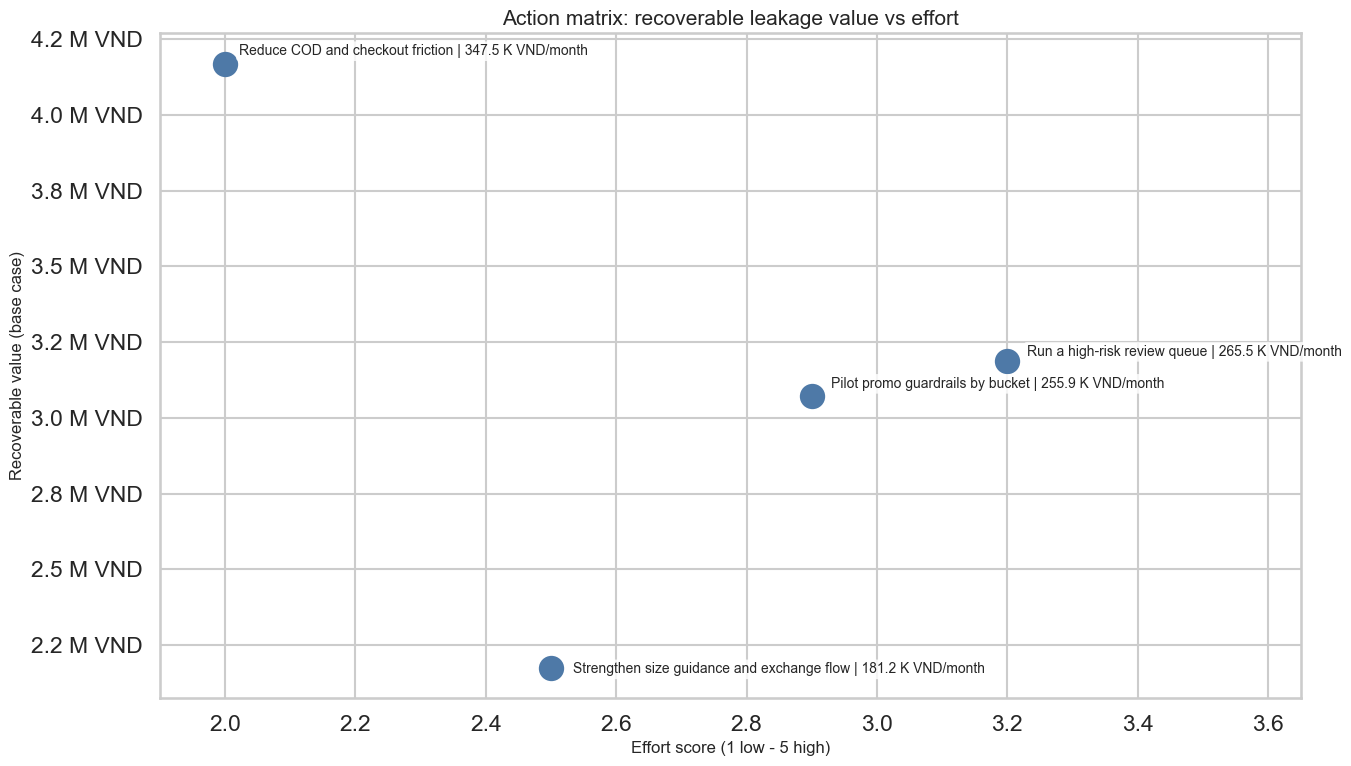

## 30-60-90 day roadmap
- The upside estimates below are sized on the `2022` scope and should be read as `value-at-stake` for pilot prioritization, not as a committed forecast.
- The combined base case across the four actions is currently `12.60` mn VND, or `8.8%` of `2022` leakage; this is a phase-one recovery estimate for the selected buckets, not the business's full potential.
- **Priority 1 - Reduce COD and checkout friction**: owner `Checkout + CRM` | KPI `Cancellation rate of the hotspot payment method` | base recoverable `4.17` mn VND | share of year leakage `2.9%`.
  Trade-off: This action can materially reduce cancellation leakage, but the checkout experience must not become so restrictive that conversion falls.
  Timeline: 30 days: remove checkout pain points; 60 days: deploy CRM nudges; 90 days: tune policy by source
- **Priority 2 - Strengthen size guidance and exchange flow**: owner `Merchandising + CX` | KPI `Wrong-size refund value and wrong-size rate` | base recoverable `2.17` mn VND | share of year leakage `1.5%`.
  Trade-off: This is lower-risk to revenue than a promo intervention, but it requires tight coordination across merchandising and CX.
  Timeline: 30 days: refine fit guidance; 60 days: launch an exchange-first flow; 90 days: optimize by bucket
- **Priority 3 - Run a high-risk review queue**: owner `Ops + Risk` | KPI `Captured leakage value share within the top review bucket` | base recoverable `3.19` mn VND | share of year leakage `2.2%`.
  Trade-off: Targeting improves, but the business pays for it through review capacity, operational SLAs, and false positives.
  Timeline: 30 days: pilot manual review; 60 days: formalize queue SLAs; 90 days: move to semi-automated routing
- **Priority 4 - Pilot promo guardrails by bucket**: owner `Growth + Finance` | KPI `Weighted margin delta promo vs no-promo` | base recoverable `3.07` mn VND | share of year leakage `2.1%`.
  Trade-off: The weakest buckets show clear margin upside, but volume can drop if the intervention is too aggressive, so it should remain a controlled pilot.
  Timeline: 30 days: freeze the weakest pilot bucket; 60 days: introduce margin guardrails; 90 days: run a bucket-level scorecard

In [20]:
eda.plot_action_matrix(action_df)

total_base_recovery = float(action_df["recoverable_base_value"].sum())
total_recovery_share = float(action_df["share_of_year_leakage"].sum())
roadmap_lines = [
    f"- The upside estimates below are sized on the `{recent_year}` scope and should be read as `value-at-stake` for pilot prioritization, not as a committed forecast.",
    f"- The combined base case across the four actions is currently `{total_base_recovery/1e6:.2f}` mn VND, or `{total_recovery_share:.1%}` of `{recent_year}` leakage; this is a phase-one recovery estimate for the selected buckets, not the business's full potential."
]
for row in action_df.itertuples(index=False):
    roadmap_lines.append(
        f"- **Priority {row.priority_rank} - {row.action}**: owner `{row.owner}` | KPI `{row.kpi}` | "
        f"base recoverable `{row.recoverable_base_value/1e6:.2f}` mn VND | share of year leakage `{row.share_of_year_leakage:.1%}`.\n"
        f"  Trade-off: {row.trade_off}\n"
        f"  Timeline: {row.timeline}"
    )

roadmap_md = "## 30-60-90 day roadmap\n" + "\n".join(roadmap_lines)
display(Markdown(roadmap_md))


In [21]:
executive_summary_md = eda.build_executive_summary(
    descriptive_points=descriptive_points,
    root_cause_df=root_cause_df,
    metrics_df=modeling_result["metrics"],
    action_df=action_df,
    review_queue_df=review_queue_df,
)
display(Markdown(executive_summary_md))


## Executive Summary

### 1. What is happening?
- In 2022, realized net revenue reached 933.63 M VND, changing +12.3% YoY, while total leakage value reached 143.31 M VND (+11.5% YoY).
- The strongest month was 04/2022 with 113.15 M VND in realized net revenue, while the month with the highest leakage pressure was 10/2022 at 17.4%.
- Streetwear led 83.9% of realized net revenue and 65.8% of resolved volume in 2022; East contributed 46.6% of realized net revenue, while 91.9% of the year's flow had already reached a final outcome.

### 2. Why is it happening?
- The drivers below were identified on the full-history resolved sample, while the action sizing uses the latest-year scope to avoid overstating upside.
- Cancellation friction: cod posts a cancellation rate of 16.9% and accounts for 26.0% of cancellation leakage (Full-history resolved sample | scope 91,443 orders | leakage 394.20 M VND).
- Wrong-size return: Streetwear | size XL shows a wrong-size rate of 1.9% and represents 26.7% of wrong-size refund value (Full-history order-line sample | refund 47.19 M VND across 121,243 order lines).
- Promotion erosion (proxy): Matched monthly comparisons within the same category and source show that Streetwear | organic_search has a proxy margin delta of -7.1 K VND (Full-history 63 matched months | year 2022 scope 1,890 promo orders | negative months 100%).

### 3. How should the triage layer operate?
- Under a review capacity of roughly 15% of orders, LogisticRegression captures 24.7% of leakage value, slightly ahead of DecisionTree (22.8%) but without a dramatic margin.
- The queue should prioritize the high-risk bucket because the queue leakage rate reaches 27.0%; the predictive layer is used as a triage mechanism, not as a full replacement for business rules.

### 4. What should happen in the next 30-60-90 days?
- The upside estimates below are sized on the latest-year scope and should be read as value-at-stake for pilot prioritization, not as a committed forecast. The combined base case across the four actions is currently about 12.60 M VND (~8.8% of the latest year's leakage).
- Reduce COD and checkout friction: base recoverable value ~ 4.17 M VND, monthly upside ~ 347.5 K VND.
- Strengthen size guidance and exchange flow: base recoverable value ~ 2.17 M VND, monthly upside ~ 181.2 K VND.
- Run a high-risk review queue: base recoverable value ~ 3.19 M VND, monthly upside ~ 265.5 K VND.